# New targets test: winsorized Delta-ratio

In [1]:
!pip install optuna xlstm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    sLSTMBlockConfig,
    mLSTMBlockConfig,
    sLSTMLayerConfig,
    mLSTMLayerConfig,
)
import optuna
from pathlib import Path as _P
import time as _time


SEED = 42
DATA_PATH = _P("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 100
PATIENCE = 15
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
OPTUNA_TRIALS = 10
N_FINAL_SEEDS = 5
N_FOLDS_FV = 5
RATIO_WINSOR_Q = (0.005, 0.995)  # per-target quantile winsorization of the ratio level (bounds from TRAIN years only)
DENOM_REL_FLOOR = 0.10           # ratio valid only if den > 0 and den >= floor * company median positive den
DENOM = {"EBITDA": "Net_Sales", "Net_Income": "Net_Sales", "ROA": "Total_Assets"}
NUM = {"EBITDA": "EBITDA", "Net_Income": "Net_Income", "ROA": "Net_Income"}   # ROA = Net_Income/Total_Assets

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing

In [3]:
from collections import defaultdict


def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    df = pd.read_csv(data_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()

    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_input_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_input_cols))
    feature_cols = [col for col in df.columns
                    if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    # Company targets size normalization
    recs = []
    n_den_dropped = {}
    for t in PREDICTION_TARGETS:
        num, den = NUM[t], DENOM[t]
        sub = year_end_records[year_end_records[t].notna()][["Company", "year", num, den]].copy()
        d = sub[den].astype(float)
        sub["_den"] = d
        pos_med = sub[sub["_den"] > 0].groupby("Company")["_den"].median()
        med = sub["Company"].map(pos_med)
        credible = (sub["_den"] > 0) & (sub["_den"] >= DENOM_REL_FLOOR * med)
        n_den_dropped[t] = int(((sub["_den"] > 0) & ~credible).sum())
        sub["ratio"] = np.where(credible, sub[num].astype(float) / sub["_den"], np.nan)
        sub["target"] = t
        recs.append(sub[["Company", "year", "target", "ratio"]])
    panel = pd.concat(recs, ignore_index=True)
    print(f"Non-credible-denominator rows set NaN per target: {n_den_dropped}")

    # winsorize the ratio level; bounds computed on TRAIN years only
    # (<= TEST_YEAR_CUTOFF) so test-period labels never depend on future data
    for t in PREDICTION_TARGETS:
        m = panel["target"] == t
        r_train = panel.loc[m & (panel["year"] <= TEST_YEAR_CUTOFF), "ratio"].to_numpy(float)
        lo, hi = np.nanpercentile(r_train, [RATIO_WINSOR_Q[0] * 100, RATIO_WINSOR_Q[1] * 100])
        panel.loc[m, "ratio"] = np.clip(panel.loc[m, "ratio"], lo, hi)
        print(f"winsor[{t}] train-only bounds: [{lo:.4f}, {hi:.4f}]")

    panel = panel.sort_values(["Company", "target", "year"]).reset_index(drop=True)
    panel_g = panel.groupby(["Company", "target"])
    panel["ratio_prev"] = panel_g["ratio"].shift(1)
    panel["d_ratio"] = panel["ratio"] - panel["ratio_prev"]          # target
    panel["d_ratio_prev"] = panel_g["d_ratio"].shift(1)

    label = defaultdict(dict)      # label[(company, year)][t] = d_ratio
    lag = defaultdict(dict)        # lag[(company, year)][t] = (ratio_prev, d_ratio_prev)
    for _, r in panel.iterrows():
        key = (r["Company"], int(r["year"]))
        if not np.isnan(r["d_ratio"]):
            label[key][r["target"]] = float(r["d_ratio"])
        if not np.isnan(r["ratio_prev"]) and not np.isnan(r["d_ratio_prev"]):
            lag[key][r["target"]] = (float(r["ratio_prev"]), float(r["d_ratio_prev"]))

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            key = (company, year)
            if key not in label or len(label[key]) < len(PREDICTION_TARGETS):
                continue
            if key not in lag or len(lag[key]) < len(PREDICTION_TARGETS):
                continue
            year_end_date = year_end_row["Date"]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[
                (company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)
            ].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            raw_window = window[feature_cols].to_numpy(dtype=np.float32)

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL"] + prior_static_cols
            mc_prior = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)
            lags = np.concatenate([
                np.array([lag[key][t][0], lag[key][t][1]], dtype=np.float32)
                for t in PREDICTION_TARGETS
            ])
            static_data = np.concatenate([mc_prior, lags])   # MC(3) + prior(9) + lags(6)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": raw_window,
                "static_data": static_data,
                "sector": sector_str,
                "window_dates": window["Date"].to_numpy(),
                "window_days": (window["Date"] - window["Date"].iloc[0]).dt.days.to_numpy(),
            })

    data_records = []
    for seq in sequences:
        key = (seq["company"], seq["year"])
        for target_name in PREDICTION_TARGETS:
            data_records.append({
                "company": seq["company"], "year": seq["year"],
                "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label[key][target_name],
                "window_data": seq["window_data"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
                "window_dates": seq["window_dates"],
                "window_days": seq["window_days"],
            })

    return pd.DataFrame(data_records), feature_cols


data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)
print(f"Total rows: {len(data_df)}")
print(f"feature_cols ({len(feature_cols)}): {feature_cols}")

Non-credible-denominator rows set NaN per target: {'EBITDA': 38, 'Net_Income': 45, 'ROA': 15}
winsor[EBITDA] train-only bounds: [-1.7235, 0.9089]
winsor[Net_Income] train-only bounds: [-2.4530, 0.7046]
winsor[ROA] train-only bounds: [-0.4971, 0.2995]
Total rows: 5955
feature_cols (34): ['Close', 'High', 'Low', 'Open', 'Volume', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'T5YIE', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_Mkt-RF', 'ff_HML', 'ff_Mom', 'Close_logret', 'Volume_log']


## Pipeline Setup: winsorized Delta-ratio targets, Sector + Prior + Lag Statics, 5-Fold TSCV

In [4]:
def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty.")
    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years: {available_years}")
    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds.")
    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")
    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) is empty. Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")
    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, _, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

def fit_static_scaler(mtl_df, new_slice):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df

SECTOR_LIST = sorted(data_df["sector"].dropna().unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
print(f"Sectors ({N_SECTORS}): {SECTOR_LIST}")

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)  # 12 dims (3 MC + 9 Prior_*)
    sector_oh = sector_onehot(sector_str)                          # N_SECTORS dims
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

# Drop samples whose prior-year fundamentals (or MC dummy) are NaN.
static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
n_drop_missing = int(static_nan_mask.sum())
data_df = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; {len(data_df)} remaining.")

data_df["static_data"] = data_df.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)
STATIC_DIM_IMP = 3 + N_SECTORS + 9 + 2 * len(PREDICTION_TARGETS)  # MC(3) + sector(N) + prior(9) + ratio lags(6)
NEW_STATIC_SLICE = slice(3 + N_SECTORS, STATIC_DIM_IMP)  # scale prior + lag block
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP} (MC=3, sector={N_SECTORS}, prior=9)")
print(f"NEW_STATIC_SLICE = {NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop} (only prior gets RobustScaler)")

def extract_mtl_df(df, new_slice=NEW_STATIC_SLICE):
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        row = group.iloc[0]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": row["year_end_date"],
            "window_data": row["window_data"],
            "static_data": row["static_data"],
            "window_dates": row["window_dates"],
            "window_days": row["window_days"],
            "label_value": label_value,
        })
    return pd.DataFrame(mtl_records)

# Target = Delta(winsorized size-normalized ratio); the ratio level is
# credibility-filtered and winsorized (train-only bounds) in the
# data-processing cell.
print("label (Delta ratio) stats:")
for _t in PREDICTION_TARGETS:
    _v = data_df.loc[data_df["target"] == _t, "label_value"].dropna().to_numpy(float)
    print(f"  {_t:11s}: n={len(_v)} mean={_v.mean():+.4f} std={_v.std():.4f} "
          f"MAD={np.mean(np.abs(_v - np.median(_v))):.4f} mean|d|={np.mean(np.abs(_v)):.4f}")
print(f"  {'pooled':11s}: mean={data_df['label_value'].mean():.4f}, std={data_df['label_value'].std():.4f}")

# Build k-fold for HPO + single-split for final test
folds, test_data = temporal_kfold_split(data_df, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF)
train_data, val_data, _ = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)

mtl_train_data_raw = extract_mtl_df(train_data)
mtl_val_data_raw   = extract_mtl_df(val_data)
mtl_test_data      = extract_mtl_df(test_data)

train_per_year = mtl_train_data_raw["year"].value_counts().sort_index()
test_per_year  = mtl_test_data["year"].value_counts().sort_index()
print(f"Train: {len(mtl_train_data_raw)} ({dict(train_per_year)})")
print(f"Test:  {len(mtl_test_data)} ({dict(test_per_year)})")

Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']
Dropped 768 samples missing prior-year fundamentals; 5187 remaining.
STATIC_DIM_IMP=28 (MC=3, sector=10, prior=9)
NEW_STATIC_SLICE = 13:28 (only prior gets RobustScaler)
label (Delta ratio) stats:
  EBITDA     : n=1729 mean=+0.0015 std=0.1811 MAD=0.0748 mean|d|=0.0748
  Net_Income : n=1729 mean=-0.0004 std=0.2094 MAD=0.0795 mean|d|=0.0795
  ROA        : n=1729 mean=-0.0015 std=0.0709 MAD=0.0355 mean|d|=0.0355
  pooled     : mean=-0.0002, std=0.1650
Available years: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (891 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (2319), val = 2019 (360)
  Fold 2: train <= 2019 (2679), val = 2020 (372)
  Fold 3: train <= 2020 (3051), val = 2021 (399)
 

## Frequencies feature selection for MultiFreqLSTM

In [5]:
DAILY_FEATURES = [
    'Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield',
    'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume',
    'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close',
    'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom',
    'TTF_Gas_Close', 'NFCI',
]
MONTHLY_FEATURES = ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
QUARTERLY_FEATURES = ['IT_GDP']

print(f"Daily ({len(DAILY_FEATURES)}): {DAILY_FEATURES}")
print(f"Monthly ({len(MONTHLY_FEATURES)}): {MONTHLY_FEATURES}")
print(f"Quarterly ({len(QUARTERLY_FEATURES)}): {QUARTERLY_FEATURES}")

daily_indices     = [feature_cols.index(f) for f in DAILY_FEATURES]
monthly_indices   = [feature_cols.index(f) for f in MONTHLY_FEATURES]
quarterly_indices = [feature_cols.index(f) for f in QUARTERLY_FEATURES]

Daily (21): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'IT10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'ff_HML', 'ff_Mom', 'TTF_Gas_Close', 'NFCI']
Monthly (5): ['Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM']
Quarterly (1): ['IT_GDP']


## Model Definitions

In [6]:
class _XLSTMMtlBackbone(nn.Module):
    """Shared xLSTM backbone for ShallowXLSTM / StackedXLSTM.

    The xLSTM package has no pack_padded_sequence support, so the (already
    padded) batch runs through xLSTMBlockStack and the last valid step is
    gathered via `lengths`. Pad tokens sit strictly AFTER the last valid step,
    so under the causal recurrence they never leak into the gathered state.
    """

    def __init__(self, input_size, embedding_dim, num_blocks, slstm_at,
                 num_targets=3, dropout=0.2, static_dim=0,
                 num_heads=4, proj_factor=2.0):
        super().__init__()
        self.static_dim = static_dim
        self.proj = nn.Linear(input_size, embedding_dim)
        mlstm_cfg = mLSTMLayerConfig(num_heads=num_heads, proj_factor=proj_factor)
        slstm_cfg = sLSTMLayerConfig(backend='vanilla')
        xlstm_config = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(mlstm=mlstm_cfg),
            slstm_block=sLSTMBlockConfig(slstm=slstm_cfg),
            context_length=400,  # > max window length (365 daily rows)
            num_blocks=num_blocks,
            embedding_dim=embedding_dim,
            slstm_at=list(slstm_at),
        )
        self.xlstm = xLSTMBlockStack(xlstm_config)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(embedding_dim + static_dim, num_targets)
        self._squeeze = (num_targets == 1)

    def forward(self, x, lengths, static=None):
        out = self.xlstm(self.proj(x))            # (B, S, embedding_dim)
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(2)).to(out.device)
        last_out = out.gather(1, idx).squeeze(1)  # (B, embedding_dim)
        hidden = self.dropout(last_out)
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if self._squeeze:
            logits = logits.squeeze(-1)
        return logits


class ShallowXLSTM(_XLSTMMtlBackbone):
    """Model A: single-block xLSTM (depth-1 counterpart of ShallowLSTM).
    block_type='mlstm' (default) or 'slstm' selects the block mix."""

    def __init__(self, input_size, hidden_size, num_targets=3, dropout=0.2,
                 static_dim=0, block_type='mlstm', num_heads=4, proj_factor=2.0):
        super().__init__(
            input_size, hidden_size, num_blocks=1,
            slstm_at=[0] if block_type == 'slstm' else [],
            num_targets=num_targets, dropout=dropout, static_dim=static_dim,
            num_heads=num_heads, proj_factor=proj_factor,
        )


class StackedXLSTM(_XLSTMMtlBackbone):
    """Model B: multi-block xLSTM (depth counterpart of StackedLSTM).
    `num_blocks` stacked blocks; `slstm_at` lists the indices of sLSTM blocks
    (e.g. [num_blocks-1] for the mLSTM/sLSTM hybrid, [] for all-mLSTM)."""

    def __init__(self, input_size, hidden_size, num_blocks=4, num_targets=3,
                 dropout=0.2, static_dim=0, slstm_at=None, num_heads=4, proj_factor=2.0):
        super().__init__(
            input_size, hidden_size, num_blocks=num_blocks,
            slstm_at=[] if slstm_at is None else list(slstm_at),
            num_targets=num_targets, dropout=dropout, static_dim=static_dim,
            num_heads=num_heads, proj_factor=proj_factor,
        )


def _slstm_at(params, num_blocks):
    """Map the searched `slstm_placement` to the sLSTM block index list."""
    placement = params.get('slstm_placement', 'none')
    if placement == 'last':
        return [num_blocks - 1]
    return []


class MultiFreqLSTM_NoQuarterly(nn.Module):
    """Two-stream variant of MultiFreqLSTM: daily + monthly only.
    Quarterly IT_GDP is folded into the monthly stream (forward-filled at
    monthly cadence), so no separate quarterly MLP is used."""
    def __init__(self, n_daily, n_monthly, n_static,
                 d_daily=64, d_monthly=32,
                 n_layers_daily=2, n_layers_monthly=1,
                 num_targets=3, dropout=0.1):
        super().__init__()
        self.daily = nn.LSTM(n_daily, d_daily, num_layers=n_layers_daily,
                            batch_first=True, dropout=0.0)
        self.monthly = nn.LSTM(n_monthly, d_monthly, num_layers=n_layers_monthly,
                              batch_first=True, dropout=0.0)
        self.merge_dim = d_daily + d_monthly + n_static
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.merge_dim, num_targets)
        self._squeeze = (num_targets == 1)

    def forward(self, daily, monthly, quarterly, lengths, static):
        packed_d = pack_padded_sequence(daily, lengths.cpu(),
                                        batch_first=True, enforce_sorted=True)
        _, (h_d, _) = self.daily(packed_d)
        h_d = h_d[-1]

        B = monthly.size(0)
        lengths_m = torch.full((B,), 12, dtype=torch.long, device=monthly.device)
        packed_m = pack_padded_sequence(monthly, lengths_m.cpu(),
                                        batch_first=True, enforce_sorted=False)
        _, (h_m, _) = self.monthly(packed_m)
        h_m = h_m[-1]

        h = torch.cat([h_d, h_m, static.to(h_d.device, h_d.dtype)], dim=-1)
        h = self.dropout(h)
        logits = self.head(h)
        if self._squeeze:
            logits = logits.squeeze(-1)
        return logits

class GroupedLSTM(nn.Module):
    """Model D: K parallel daily LSTM streams, one per group of temporally
    correlated features. Groups are found via hierarchical clustering of the
    Spearman correlation (computed on training data only). All streams share
    the same daily (252-step) cadence, so no sequence packing is needed."""
    def __init__(self, group_sizes, hidden_sizes, n_layers, n_static,
                 num_targets=3, dropout=0.1):
        super().__init__()
        self.n_groups = len(group_sizes)
        self.streams = nn.ModuleList([
            nn.LSTM(group_sizes[g], hidden_sizes[g], num_layers=n_layers[g],
                    batch_first=True, dropout=0.0)
            for g in range(self.n_groups)
        ])
        self.merge_dim = int(sum(hidden_sizes)) + n_static
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.merge_dim, num_targets)
        self._squeeze = (num_targets == 1)

    def forward(self, groups, static):
        hs = []
        for g in range(self.n_groups):
            _, (hn, _) = self.streams[g](groups[g])
            hs.append(hn[-1])
        h = torch.cat(hs + [static.to(hs[0].device, hs[0].dtype)], dim=-1)
        h = self.dropout(h)
        logits = self.head(h)
        if self._squeeze:
            logits = logits.squeeze(-1)
        return logits


class MultiFreqLSTM_DS(MultiFreqLSTM_NoQuarterly):
    """Model E: MultiFreqLSTM_NoQuarterly + deep supervision.
    One auxiliary head per intermediate layer of the daily LSTM: aux head l is
    Linear(d_daily, num_targets) on layer l's final hidden state h_d[l]. With
    the default n_layers_daily=2 this is a single aux head on layer 1. The
    monthly stream has n_layers_monthly=1 (no intermediate layer), so it gets
    no aux head.
    In train mode forward returns (logits, [aux, ...]), to be consumed by
    make_ds_loss_fn; in eval mode it returns plain logits, so every evaluation
    helper (collect_predictions, evaluate_loader, ...) works unchanged."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        n_intermediate = self.daily.num_layers - 1
        self.aux_heads = nn.ModuleList([
            nn.Linear(self.daily.hidden_size, self.head.out_features)
            for _ in range(n_intermediate)
        ])

    def forward(self, daily, monthly, quarterly, lengths, static):
        packed_d = pack_padded_sequence(daily, lengths.cpu(),
                                        batch_first=True, enforce_sorted=True)
        _, (h_d, _) = self.daily(packed_d)   # h_d: (n_layers_daily, B, d_daily)
        aux = [aux_head(h_d[l]) for l, aux_head in enumerate(self.aux_heads)]
        h_d = h_d[-1]

        B = monthly.size(0)
        lengths_m = torch.full((B,), 12, dtype=torch.long, device=monthly.device)
        packed_m = pack_padded_sequence(monthly, lengths_m.cpu(),
                                        batch_first=True, enforce_sorted=False)
        _, (h_m, _) = self.monthly(packed_m)
        h_m = h_m[-1]

        h = torch.cat([h_d, h_m, static.to(h_d.device, h_d.dtype)], dim=-1)
        h = self.dropout(h)
        logits = self.head(h)
        if self._squeeze:
            logits = logits.squeeze(-1)
            aux = [a.squeeze(-1) for a in aux]
        if self.training:
            return logits, aux
        return logits

selected_indices = [feature_cols.index(f) for f in (DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES)]

print("Models defined: ShallowXLSTM, StackedXLSTM, MultiFreqLSTM_NoQuarterly, GroupedLSTM, MultiFreqLSTM_DS")

GROUPED_K = 3
GROUPED_HIDDEN_SIZES = [64, 32, 32]
GROUPED_N_LAYERS = [2, 1, 1]


Models defined: ShallowXLSTM, StackedXLSTM, MultiFreqLSTM_NoQuarterly, GroupedLSTM, MultiFreqLSTM_DS


## Datasets & DataLoaders

In [7]:
def aggregate_to_cadence(window_dates, window_days, raw_window, target_indices, n_steps):
    """Aggregate a raw window to `n_steps` evenly-spaced bins (by day of year).
    raw_window: (T, F) array; target_indices: list of feature column indices to keep.
    Returns (n_steps, len(target_indices)) array, with NaN if no observations.
    """
    T = raw_window.shape[0]
    if T < 2:
        return np.full((n_steps, len(target_indices)), np.nan, dtype=np.float32)
    last_day = float(window_days[-1])
    if last_day <= 0:
        return np.full((n_steps, len(target_indices)), np.nan, dtype=np.float32)
    bin_size = last_day / n_steps
    out = np.full((n_steps, len(target_indices)), np.nan, dtype=np.float32)
    if len(target_indices) == 0:
        return out
    # Assign each timestep to its bin
    bin_idx = np.minimum((window_days / bin_size).astype(int), n_steps - 1)
    for f_i, f_idx in enumerate(target_indices):
        col = raw_window[:, f_idx]
        for b in range(n_steps):
            mask = bin_idx == b
            if mask.any():
                vals = col[mask]
                vals = vals[~np.isnan(vals)]
                if len(vals) > 0:
                    out[b, f_i] = vals[-1]  # take last non-NaN value (forward-fill)
    return out

def build_multifreq_window(raw_window, window_days, daily_idx, monthly_idx, quarterly_idx,
                            n_daily=252, n_monthly=12, n_quarterly=4):
    """Aggregate the raw window to the 3 cadences."""
    daily    = aggregate_to_cadence(None, window_days, raw_window, daily_idx,     n_daily)
    monthly  = aggregate_to_cadence(None, window_days, raw_window, monthly_idx,   n_monthly)
    quarterly = aggregate_to_cadence(None, window_days, raw_window, quarterly_idx, n_quarterly)
    # Forward-fill along the time axis (within stream)
    for arr in (daily, monthly, quarterly):
        for f in range(arr.shape[1]):
            last = np.nan
            for t in range(arr.shape[0]):
                if np.isnan(arr[t, f]):
                    arr[t, f] = last
                else:
                    last = arr[t, f]
            # Backward-fill leading NaNs
            if np.isnan(arr[0, f]):
                first_valid = np.nan
                for t in range(arr.shape[0]):
                    if not np.isnan(arr[t, f]):
                        first_valid = arr[t, f]
                        break
                arr[:, f] = first_valid
    # Replace any remaining NaN with 0
    daily    = np.nan_to_num(daily,    nan=0.0).astype(np.float32)
    monthly  = np.nan_to_num(monthly,  nan=0.0).astype(np.float32)
    quarterly = np.nan_to_num(quarterly, nan=0.0).astype(np.float32)
    return daily, monthly, quarterly

# Module-level cache for build_multifreq_window results. The aggregation is
# deterministic given (window, window_days, indices, steps), so serving it from
# this cache is bit-identical to recomputing; it just avoids redoing the
# pure-Python binning on every __getitem__/epoch, which dominated wall time
# for the multi-frequency models. Keys include the full spec, so different
# GroupedDataset group orderings (per fold) never collide. The cache is
# filled in the main process when a Dataset is constructed; forked
# DataLoader workers inherit it.
_MFW_CACHE = {}

def _mfw_key_multifreq(company, year, daily_idx, monthly_idx, quarterly_idx,
                       n_daily, n_monthly, n_quarterly):
    return (str(company), int(year), tuple(daily_idx), tuple(monthly_idx),
            tuple(quarterly_idx), int(n_daily), int(n_monthly), int(n_quarterly))

def _mfw_key_grouped(company, year, all_idx, n_daily):
    return (str(company), int(year), tuple(all_idx), int(n_daily), "grouped")

class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler is not None:
            window = self.scaler.transform(window)
            # Sanitize: RobustScaler can produce NaN/Inf
            window = np.nan_to_num(window, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        static = row["static_data"].astype(np.float32)
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window),
        )

def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths

class MultiFreqDataset(Dataset):
    def __init__(self, mtl_df, daily_scaler, monthly_scaler, quarterly_scaler, stat_scaler,
                 daily_idx, monthly_idx, quarterly_idx, n_daily=252, n_monthly=12, n_quarterly=4):
        self.mtl_df = mtl_df.reset_index(drop=True)
        self.daily_scaler = daily_scaler
        self.monthly_scaler = monthly_scaler
        self.quarterly_scaler = quarterly_scaler
        self.stat_scaler = stat_scaler
        self.daily_idx = daily_idx
        self.monthly_idx = monthly_idx
        self.quarterly_idx = quarterly_idx
        self.n_daily = n_daily
        self.n_monthly = n_monthly
        self.n_quarterly = n_quarterly
        # Precompute the aggregation once per sample; cached across dataset
        # instances, so later constructions (val/test, other seeds) hit the cache.
        self._mf_keys = []
        for _, _row in self.mtl_df.iterrows():
            _key = _mfw_key_multifreq(_row["company"], _row["year"],
                                      self.daily_idx, self.monthly_idx, self.quarterly_idx,
                                      self.n_daily, self.n_monthly, self.n_quarterly)
            if _key not in _MFW_CACHE:
                _MFW_CACHE[_key] = build_multifreq_window(
                    _row["window_data"], _row["window_days"],
                    self.daily_idx, self.monthly_idx, self.quarterly_idx,
                    n_daily=self.n_daily, n_monthly=self.n_monthly, n_quarterly=self.n_quarterly,
                )
            self._mf_keys.append(_key)

    def __len__(self):
        return len(self.mtl_df)

    def __getitem__(self, idx):
        row = self.mtl_df.iloc[idx]
        d, m, q = _MFW_CACHE[self._mf_keys[idx]]
        if self.daily_scaler is not None:
            d = self.daily_scaler.transform(d)
            d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.monthly_scaler is not None:
            m = self.monthly_scaler.transform(m)
            m = np.nan_to_num(m, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.quarterly_scaler is not None:
            q = self.quarterly_scaler.transform(q)
            q = np.nan_to_num(q, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        if self.stat_scaler is not None:
            static = self.stat_scaler.transform(
                row["static_data"].reshape(1, -1)
            ).reshape(-1).astype(np.float32)
        else:
            static = row["static_data"].astype(np.float32)
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(d.astype(np.float32)),
            torch.from_numpy(m.astype(np.float32)),
            torch.from_numpy(q.astype(np.float32)),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            self.n_daily,
        )

def collate_fn_multifreq(batch):
    batch.sort(key=lambda x: x[6], reverse=True)
    ds = torch.stack([x[0] for x in batch])
    ms = torch.stack([x[1] for x in batch])
    qs = torch.stack([x[2] for x in batch])
    statics = torch.stack([x[3] for x in batch])
    targets = torch.stack([x[4] for x in batch])
    masks = torch.stack([x[5] for x in batch])
    lengths = torch.tensor([x[6] for x in batch])
    return ds, ms, qs, targets, masks, statics, lengths


class GroupedDataset(Dataset):
    """Model D dataset: daily-aggregated window split into K correlated-feature
    groups. Returns K group tensors (all (n_daily, group_size)) + static/target/mask."""
    def __init__(self, mtl_df, group_idx_list, scaler, stat_scaler, n_daily=252):
        self.mtl_df = mtl_df.reset_index(drop=True)
        self.group_idx_list = [list(g) for g in group_idx_list]
        self.scaler = scaler
        self.stat_scaler = stat_scaler
        self.n_daily = n_daily
        self.all_idx = [idx for g in self.group_idx_list for idx in g]
        # Precompute the aggregation once per sample (cached, see _MFW_CACHE)
        self._gd_keys = []
        for _, _row in self.mtl_df.iterrows():
            _key = _mfw_key_grouped(_row["company"], _row["year"], self.all_idx, self.n_daily)
            if _key not in _MFW_CACHE:
                _MFW_CACHE[_key] = build_multifreq_window(
                    _row["window_data"], _row["window_days"], self.all_idx, [], [],
                    n_daily=self.n_daily,
                )
            self._gd_keys.append(_key)

    def __len__(self):
        return len(self.mtl_df)

    def __getitem__(self, idx):
        row = self.mtl_df.iloc[idx]
        d, _, _ = _MFW_CACHE[self._gd_keys[idx]]
        if self.scaler is not None:
            d = self.scaler.transform(d)
            d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        groups = []
        col = 0
        for g in self.group_idx_list:
            groups.append(torch.from_numpy(d[:, col:col + len(g)]))
            col += len(g)
        static = row["static_data"].astype(np.float32)
        if self.stat_scaler is not None:
            static = self.stat_scaler.transform(
                static.reshape(1, -1)
            ).reshape(-1).astype(np.float32)
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            *groups,
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
        )


def collate_fn_grouped(batch):
    n_groups = len(batch[0]) - 3
    group_tensors = [torch.stack([x[g] for x in batch]) for g in range(n_groups)]
    statics = torch.stack([x[n_groups] for x in batch])
    targets = torch.stack([x[n_groups + 1] for x in batch])
    masks = torch.stack([x[n_groups + 2] for x in batch])
    return (*group_tensors, targets, masks, statics)


## Correlation feature grouping for GroupedLSTM (Model D)


In [8]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

def compute_corr_groups(mtl_df, feature_indices, k=3):
    """Cluster `feature_indices` into `k` groups by Spearman correlation over time."""
    n_daily = 252
    pooled = []
    for _, row in mtl_df.iterrows():
        d, _, _ = build_multifreq_window(row["window_data"], row["window_days"],
                                         feature_indices, [], [], n_daily=n_daily)
        d = np.nan_to_num(d, nan=0.0, posinf=0.0, neginf=0.0)
        mu = d.mean(axis=0, keepdims=True)
        sd = d.std(axis=0, keepdims=True) + 1e-8
        pooled.append((d - mu) / sd)
    X = np.vstack(pooled)
    corr = pd.DataFrame(X).corr(method="spearman").to_numpy()
    corr = np.nan_to_num(corr, nan=0.0)
    dist = 1.0 - np.abs(corr)
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist), method="average")
    labels = fcluster(Z, t=k, criterion="maxclust")
    groups = []
    for c in sorted(set(labels)):
        groups.append([feature_indices[i] for i in range(len(feature_indices)) if labels[i] == c])
    return groups

def describe_corr_groups(groups):
    return [[feature_cols[i] for i in g] for g in groups]

_demo_mtl = extract_mtl_df(train_data)
_demo_groups = compute_corr_groups(_demo_mtl, selected_indices, k=3)
for _gi, _g in enumerate(describe_corr_groups(_demo_groups), start=1):
    print(f"Group {_gi} ({len(_g)}): {_g}")


Group 1 (24): ['Volume_log', 'DE10YT_Yield', 'IT10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 'Brent_Close', 'Brent_Volume', 'OVX_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'TTF_Gas_Close', 'NFCI', 'Euribor_3M', 'IT_Inflation', 'IT_Unemployment', 'PCOPPUSDM', 'PALUMUSDM', 'IT_GDP']
Group 2 (2): ['ff_HML', 'ff_Mom']
Group 3 (1): ['Close_logret']


## Training with Regularization setup

In [9]:
def fwd_mtl(batch):
    """Shallow/Stacked LSTM batch -> (model_args, targets, mask), on DEVICE."""
    bx, by, bmask, bstatic, lengths = batch
    return ((bx.to(DEVICE), lengths, bstatic.to(DEVICE)),
            by.to(DEVICE), bmask.to(DEVICE))


def fwd_mf(batch):
    """MultiFreqLSTM batch -> (model_args, targets, mask), on DEVICE."""
    bd, bm, bq, by, bmask, bstatic, lengths = batch
    return ((bd.to(DEVICE), bm.to(DEVICE), bq.to(DEVICE), lengths, bstatic.to(DEVICE)),
            by.to(DEVICE), bmask.to(DEVICE))


def fwd_grouped(batch):
    """GroupedLSTM batch -> (model_args, targets, mask), on DEVICE."""
    *groups, by, bmask, bstatic = batch
    return (([g.to(DEVICE) for g in groups], bstatic.to(DEVICE)),
            by.to(DEVICE), bmask.to(DEVICE))


def collect_predictions(model, loader, adapt):
    """Run model on loader; return (preds, targets, mask) numpy arrays."""
    model.eval()
    P, T, M = [], [], []
    with torch.no_grad():
        for batch in loader:
            args, by, bmask = adapt(batch)
            logits = model(*args)
            P.append(logits.cpu().numpy())
            T.append(by.cpu().numpy())
            M.append(bmask.cpu().numpy())
    if not P:
        return None
    return np.vstack(P), np.vstack(T), np.vstack(M).astype(bool)


def evaluate_loader(model, loader, adapt):
    """Per-target + Overall MAE (Delta-ratio space) on a loader."""
    out = collect_predictions(model, loader, adapt)
    if out is None:
        return None
    yp, yt, mask = out
    res = {}
    all_err = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        errs = np.abs(yp[m, i] - yt[m, i])
        res[t] = float(errs.mean())
        all_err.extend(errs.tolist())
    res["Overall"] = float(np.mean(all_err)) if all_err else None
    return res


def train_and_eval(model, train_loader, val_loader, optimizer, adapt,
                   trial=None, step_offset=0, collect_history=False, loss_fn=None):
    criterion = nn.L1Loss(reduction='none')
    if loss_fn is None:
        def loss_fn(model_out, by, bmask):
            loss_m = criterion(model_out, by)
            return loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0 * loss_m.sum()
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    best_state = None
    best_metric = float("inf")
    epochs_no_improve = 0
    best_epoch = 0
    train_loss_history = []
    val_metric_history = []
    val_loss_history = []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss_epoch = 0.0
        n_batches = 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            args, by, bmask = adapt(batch)
            logits = model(*args)
            loss = loss_fn(logits, by, bmask)
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                if not torch.isfinite(loss):
                    continue
                train_loss_epoch += loss.item()
                n_batches += 1
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        out = collect_predictions(model, val_loader, adapt)
        if out is None:
            break
        y_pred, y_true, mask = out
        valid_sum, count = 0.0, 0
        for i in range(len(PREDICTION_TARGETS)):
            m = mask[:, i]
            if m.sum() == 0:
                continue
            valid_sum += np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
            count += 1
        current_metric = valid_sum / max(1, count)
        scheduler.step(current_metric)
        val_metric_history.append(current_metric)
        val_loss_history.append(current_metric)  # same Delta-ratio L1 space as train loss
        train_loss_history.append(train_loss_epoch / max(1, n_batches))

        if np.isfinite(current_metric) and current_metric < best_metric:
            best_metric = current_metric
            best_state = {n: t.detach().cpu().clone() for n, t in model.state_dict().items()}
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if trial is not None:
            trial.report(current_metric, step_offset + epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        if epochs_no_improve >= PATIENCE:
            break

    history = {
        'epochs': list(range(1, len(val_metric_history) + 1)),
        'train_loss': train_loss_history,
        'val_metric': val_metric_history,
        'val_loss': val_loss_history,
        'best_epoch': best_epoch,
    }
    if best_state is not None:
        model.load_state_dict(best_state)
    if collect_history:
        return model, best_metric, best_epoch, history
    return model, best_metric, best_epoch


def make_ds_loss_fn(aux_weight):
    """Deep-supervision loss for MultiFreqLSTM_DS, whose train-mode forward
    returns (logits, [aux_logits, ...]): masked L1 on the main head plus
    `aux_weight` * masked L1 on each auxiliary head.
    aux_weight=0.0 recovers the baseline Model C objective."""
    criterion = nn.L1Loss(reduction='none')

    def _masked_l1(pred, by, bmask):
        loss_m = criterion(pred, by)
        return loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0 * loss_m.sum()

    def ds_loss_fn(model_out, by, bmask):
        logits, aux_logits = model_out
        loss = _masked_l1(logits, by, bmask)
        for aux in aux_logits:
            loss = loss + aux_weight * _masked_l1(aux, by, bmask)
        return loss

    return ds_loss_fn


print("Training/eval helpers ready.")


Training/eval helpers ready.


## Loader builders per model

In [10]:
def build_mtl_loaders_for_fold(tr_df, va_df, params, feature_indices, static_dim):
    """Build train/val/test loaders for MTL (Shallow or Stacked xLSTM).
    Returns (train_loader, val_loader, test_loader, scaler, stat_scaler)."""
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    temp_sc = make_robust_scaler(tr_mtl, feature_indices)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = YoYDatasetMTL(tr_mtl_s, temp_sc, feature_indices)
    va_ds = YoYDatasetMTL(va_mtl_s, temp_sc, feature_indices)
    te_ds = YoYDatasetMTL(te_mtl_s, temp_sc, feature_indices)
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_mtl)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    return tr_loader, va_loader, te_loader, temp_sc, stat_sc

def make_shallow_mtl(tr_df, va_df, params, feature_indices):
    tr_loader, va_loader, te_loader, _, _ = build_mtl_loaders_for_fold(
        tr_df, va_df, params, feature_indices, STATIC_DIM_IMP)
    model = ShallowXLSTM(
        input_size=len(feature_indices),
        hidden_size=params['hidden_size'],
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.2),
        static_dim=STATIC_DIM_IMP,
        block_type=params.get('block_type', 'mlstm'),
        num_heads=params.get('num_heads', 4),
        proj_factor=params.get('proj_factor', 2.0),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader

def make_stacked_mtl(tr_df, va_df, params, feature_indices, num_blocks=4):
    tr_loader, va_loader, te_loader, _, _ = build_mtl_loaders_for_fold(
        tr_df, va_df, params, feature_indices, STATIC_DIM_IMP)
    n_blocks = params.get('num_blocks', num_blocks)
    model = StackedXLSTM(
        input_size=len(feature_indices),
        hidden_size=params['hidden_size'],
        num_blocks=n_blocks,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.2),
        static_dim=STATIC_DIM_IMP,
        slstm_at=_slstm_at(params, n_blocks),
        num_heads=params.get('num_heads', 4),
        proj_factor=params.get('proj_factor', 2.0),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


# Optuna Search

In [ ]:
def get_hpo_objective_mtl(make_model_fn, feature_indices, n_trials=OPTUNA_TRIALS,
                          search_block_mix=False, search_num_blocks=False):
    """HPO objective for the xLSTM Models A/B. `search_block_mix` adds the
    mLSTM-vs-sLSTM block choice (Model A); `search_num_blocks` adds the depth
    and sLSTM-placement search (Model B). Both add the mLSTM num_heads and
    proj_factor to the shared search space (hidden_size must be divisible by
    num_heads, otherwise the trial is pruned immediately)."""
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    temp_sc = make_robust_scaler(tr_mtl, feature_indices)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.5)
        num_heads = trial.suggest_categorical("num_heads", [2, 4])
        proj_factor = trial.suggest_categorical("proj_factor", [1.0, 2.0])
        if hidden_size % num_heads != 0:
            raise optuna.TrialPruned()
        params = dict(hidden_size=hidden_size, lr=lr, batch_size=batch_size,
                      weight_decay=weight_decay, dropout=dropout,
                      num_heads=num_heads, proj_factor=proj_factor)
        if search_block_mix:
            params["block_type"] = trial.suggest_categorical("block_type", ["mlstm", "slstm"])
        if search_num_blocks:
            params["num_blocks"] = trial.suggest_categorical("num_blocks", [2, 3, 4])
            params["slstm_placement"] = trial.suggest_categorical("slstm_placement", ["none", "last"])
        tr_ds = YoYDatasetMTL(tr_mtl_s, temp_sc, feature_indices)
        va_ds = YoYDatasetMTL(va_mtl_s, temp_sc, feature_indices)
        tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn_mtl)
        va_loader = DataLoader(va_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_mtl)
        model = make_model_fn(params, feature_indices)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_mtl,
                trial=trial, step_offset=0,
            )
        except optuna.exceptions.TrialPruned:
            raise
        return best_metric
    return objective

def run_optuna(study_name, objective_fn, n_trials=OPTUNA_TRIALS, seed_trials=None):
    pruner = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=study_name, pruner=pruner)
    for t in (seed_trials or []):
        study.enqueue_trial(t)
    study.optimize(objective_fn, n_trials=n_trials)
    return study


## Model A: Shallow xLSTM (block mix searched: mLSTM vs sLSTM)


In [ ]:
selected_indices = [feature_cols.index(f) for f in (DAILY_FEATURES + MONTHLY_FEATURES + QUARTERLY_FEATURES)]
print(f"Using {len(selected_indices)} features for Shallow/Stacked xLSTM input.")

def make_shallow_fn(params, fi):
    model = ShallowXLSTM(
        len(selected_indices), params['hidden_size'], len(PREDICTION_TARGETS),
        params.get('dropout', 0.2), static_dim=STATIC_DIM_IMP,
        block_type=params.get('block_type', 'mlstm'),
        num_heads=params.get('num_heads', 4),
        proj_factor=params.get('proj_factor', 2.0),
    ).to(DEVICE)
    return model

_t0 = _time.time()
study_A = run_optuna(
    "shallow_xlstm",
    get_hpo_objective_mtl(make_shallow_fn, selected_indices, search_block_mix=True),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nShallow xLSTM best val MAE: {study_A.best_value:.4f}")
print(f"Best params: {study_A.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")


Using 27 features for Shallow/Stacked xLSTM input.


[I 2026-08-30 14:34:15,906] A new study created in memory with name: shallow_xlstm
[I 2026-08-30 14:36:41,653] Trial 0 finished with value: 0.047278642654418945 and parameters: {'hidden_size': 64, 'lr': 0.00019459890242714168, 'batch_size': 32, 'weight_decay': 4.688121583330088e-05, 'dropout': 0.24587366077070782, 'num_heads': 4, 'proj_factor': 2.0, 'block_type': 'mlstm'}. Best is trial 0 with value: 0.047278642654418945.
[I 2026-08-30 14:38:39,846] Trial 1 finished with value: 0.052059222012758255 and parameters: {'hidden_size': 32, 'lr': 0.000163313004683742, 'batch_size': 64, 'weight_decay': 5.1929991780668086e-05, 'dropout': 0.39787076303381574, 'num_heads': 4, 'proj_factor': 2.0, 'block_type': 'mlstm'}. Best is trial 0 with value: 0.047278642654418945.
[I 2026-08-30 14:46:57,653] Trial 2 finished with value: 0.04393388703465462 and parameters: {'hidden_size': 32, 'lr': 0.0029662648092608386, 'batch_size': 64, 'weight_decay': 0.0001591320339454645, 'dropout': 0.2815122389277962, 'n

## Model B: Stacked xLSTM (num_blocks and sLSTM placement searched)


In [ ]:
def make_stacked_fn(params, fi):
    n_blocks = params.get('num_blocks', 4)
    model = StackedXLSTM(
        input_size=len(selected_indices),
        hidden_size=params['hidden_size'],
        num_blocks=n_blocks,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.2),
        static_dim=STATIC_DIM_IMP,
        slstm_at=_slstm_at(params, n_blocks),
        num_heads=params.get('num_heads', 4),
        proj_factor=params.get('proj_factor', 2.0),
    ).to(DEVICE)
    return model

_t0 = _time.time()
study_B = run_optuna(
    "stacked_xlstm",
    get_hpo_objective_mtl(make_stacked_fn, selected_indices, search_num_blocks=True),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nStacked xLSTM best val MAE: {study_B.best_value:.4f}")
print(f"Best params: {study_B.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")


[I 2026-08-30 16:38:28,292] A new study created in memory with name: stacked_xlstm
[I 2026-08-30 16:43:35,735] Trial 0 finished with value: 0.043290432542562485 and parameters: {'hidden_size': 128, 'lr': 0.0034497899536582275, 'batch_size': 16, 'weight_decay': 0.0005117227259426682, 'dropout': 0.04715158127112451, 'num_heads': 2, 'proj_factor': 1.0, 'num_blocks': 4, 'slstm_placement': 'none'}. Best is trial 0 with value: 0.043290432542562485.
[I 2026-08-30 16:45:08,087] Trial 1 finished with value: 0.0936037003993988 and parameters: {'hidden_size': 128, 'lr': 0.00013057582571071065, 'batch_size': 16, 'weight_decay': 0.00028494721654188335, 'dropout': 0.31304349552058286, 'num_heads': 2, 'proj_factor': 2.0, 'num_blocks': 2, 'slstm_placement': 'none'}. Best is trial 0 with value: 0.043290432542562485.
[I 2026-08-30 16:47:24,176] Trial 2 finished with value: 0.0434345118701458 and parameters: {'hidden_size': 64, 'lr': 0.00524877105283443, 'batch_size': 32, 'weight_decay': 2.23902349058702


Stacked xLSTM best val MAE: 0.0428
Best params: {'hidden_size': 128, 'lr': 0.0048553228141650995, 'batch_size': 16, 'weight_decay': 1.4414219304614172e-06, 'dropout': 0.25811340240847697, 'num_heads': 4, 'proj_factor': 2.0, 'num_blocks': 3, 'slstm_placement': 'last'}
Optuna time: 88.7 min


## Model C: MultiFreqLSTM (Daily and Monthly only)


In [ ]:
OPTUNA_TRIALS = 20

def make_mf_c_fn_for_optuna(params):
    model = MultiFreqLSTM_NoQuarterly(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_indices) + len(quarterly_indices),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model

def get_hpo_objective_mf_gdp():
    """IT_GDP is folded into the monthly stream"""
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    monthly_gdp_idx = monthly_indices + quarterly_indices
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        params = dict(
            batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
            lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            dropout=trial.suggest_float("dropout", 0.1, 0.5),
            n_layers_daily=2,
            n_layers_monthly=1,
        )
        tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                                 daily_indices, monthly_gdp_idx, [])
        va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                                 daily_indices, monthly_gdp_idx, [])
        tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq)
        va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
        model = make_mf_c_fn_for_optuna(params)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_mf,
                trial=trial, step_offset=0,
            )
        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            print(f"Trial failed: {type(e).__name__}: {e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return float('inf')
        return best_metric
    return objective

_t0 = _time.time()
study_C = run_optuna(
    "multifreq_c_reg",
    get_hpo_objective_mf_gdp(),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nMultiFreqLSTM best val MAE: {study_C.best_value:.4f}")
print(f"Best params: {study_C.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")

[I 2026-08-30 20:51:15,896] A new study created in memory with name: multifreq_c_reg
[I 2026-08-30 20:54:42,683] Trial 0 finished with value: 0.04461708292365074 and parameters: {'batch_size': 16, 'lr': 0.0006214786902120268, 'weight_decay': 5.825682065738038e-06, 'dropout': 0.30554816841551335}. Best is trial 0 with value: 0.04461708292365074.
[I 2026-08-30 20:56:01,551] Trial 1 finished with value: 0.04512104019522667 and parameters: {'batch_size': 16, 'lr': 0.0013543830498091638, 'weight_decay': 2.2795294954258364e-06, 'dropout': 0.3554544159165054}. Best is trial 0 with value: 0.04461708292365074.
[I 2026-08-30 20:58:14,114] Trial 2 finished with value: 0.04907478019595146 and parameters: {'batch_size': 64, 'lr': 0.0002314642682366087, 'weight_decay': 0.00035134550725711384, 'dropout': 0.2276568369782385}. Best is trial 0 with value: 0.04461708292365074.
[I 2026-08-30 20:59:02,364] Trial 3 finished with value: 0.045888885855674744 and parameters: {'batch_size': 64, 'lr': 0.00418178


MultiFreqLSTM best val MAE: 0.0438
Best params: {'batch_size': 64, 'lr': 0.0005537423504723057, 'weight_decay': 1.0998221237042259e-06, 'dropout': 0.16788408358369425}
Optuna time: 25.3 min


## Model D: GroupedLSTM (correlation-grouped, daily cadence)


In [ ]:
def make_grouped_d_fn_for_optuna(params, group_sizes):
    model = GroupedLSTM(
        group_sizes=group_sizes,
        hidden_sizes=params.get('hidden_sizes', GROUPED_HIDDEN_SIZES),
        n_layers=params.get('n_layers', GROUPED_N_LAYERS),
        n_static=STATIC_DIM_IMP,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model

def get_hpo_objective_grouped():
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    groups = compute_corr_groups(tr_mtl, selected_indices, k=GROUPED_K)
    group_sizes = [len(g) for g in groups]
    all_idx = [i for g in groups for i in g]
    scaler = make_robust_scaler(tr_mtl, all_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        params = dict(
            batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
            lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            dropout=trial.suggest_float("dropout", 0.1, 0.5),
            hidden_sizes=GROUPED_HIDDEN_SIZES,
            n_layers=GROUPED_N_LAYERS,
        )
        tr_ds = GroupedDataset(tr_mtl_s, groups, scaler, None, n_daily=252)
        va_ds = GroupedDataset(va_mtl_s, groups, scaler, None, n_daily=252)
        tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_grouped)
        va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_grouped)
        model = make_grouped_d_fn_for_optuna(params, group_sizes)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_grouped,
                trial=trial, step_offset=0,
            )
        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            print(f"Trial failed: {type(e).__name__}: {e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return float('inf')
        return best_metric
    return objective

_t0 = _time.time()
study_D = run_optuna(
    "grouped_d_reg",
    get_hpo_objective_grouped(),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nGroupedLSTM best val MAE: {study_D.best_value:.4f}")
print(f"Best params: {study_D.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")


[I 2026-08-30 21:17:52,854] A new study created in memory with name: grouped_d_reg
[I 2026-08-30 21:20:28,266] Trial 0 finished with value: 0.04425482824444771 and parameters: {'batch_size': 64, 'lr': 0.006288432855735171, 'weight_decay': 1.0235791274879984e-06, 'dropout': 0.23974986478900845}. Best is trial 0 with value: 0.04425482824444771.
[I 2026-08-30 21:21:25,963] Trial 1 finished with value: 0.04398496821522713 and parameters: {'batch_size': 32, 'lr': 0.00278816421313891, 'weight_decay': 0.0007254641953466898, 'dropout': 0.16481710655981888}. Best is trial 1 with value: 0.04398496821522713.
[I 2026-08-30 21:22:45,002] Trial 2 finished with value: 0.04359438642859459 and parameters: {'batch_size': 16, 'lr': 0.004142944955908398, 'weight_decay': 3.7241827755563255e-05, 'dropout': 0.11222611615591212}. Best is trial 2 with value: 0.04359438642859459.
[I 2026-08-30 21:23:39,696] Trial 3 finished with value: 0.04364297166466713 and parameters: {'batch_size': 64, 'lr': 0.0015119987258


GroupedLSTM best val MAE: 0.0431
Best params: {'batch_size': 64, 'lr': 0.00450725961161414, 'weight_decay': 7.841453642221816e-06, 'dropout': 0.10422355878323203}
Optuna time: 17.6 min


## Model E: MultiFreqLSTM-Deep Supervision

In [ ]:
def make_mf_ds_fn_for_optuna(params):
    model = MultiFreqLSTM_DS(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_indices) + len(quarterly_indices),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model

def get_hpo_objective_mf_ds():
    """Model C + deep supervision. IT_GDP is folded into the monthly stream.
    aux_weight is part of the search space; 0.0 recovers the Model C baseline."""
    fold_local = folds[-1]
    tr_df, va_df, val_year, _ = fold_local
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    monthly_gdp_idx = monthly_indices + quarterly_indices
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)

    def objective(trial):
        params = dict(
            batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
            lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            weight_decay=trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
            dropout=trial.suggest_float("dropout", 0.1, 0.5),
            n_layers_daily=2,
            n_layers_monthly=1,
            aux_weight=trial.suggest_categorical("aux_weight", [0.0, 0.05, 0.1, 0.2, 0.3]),
        )
        tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                                 daily_indices, monthly_gdp_idx, [])
        va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                                 daily_indices, monthly_gdp_idx, [])
        tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq)
        va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq)
        model = make_mf_ds_fn_for_optuna(params)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        try:
            _, best_metric, _ = train_and_eval(
                model, tr_loader, va_loader, optimizer, fwd_mf,
                trial=trial, step_offset=0,
                loss_fn=make_ds_loss_fn(params['aux_weight']),
            )
        except optuna.exceptions.TrialPruned:
            raise
        except Exception as e:
            print(f"Trial failed: {type(e).__name__}: {e}")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return float('inf')
        return best_metric
    return objective

_t0 = _time.time()
study_E = run_optuna(
    "multifreq_ds_reg",
    get_hpo_objective_mf_ds(),
    n_trials=OPTUNA_TRIALS,
)
print(f"\nMultiFreqLSTM-DS best val MAE: {study_E.best_value:.4f}")
print(f"Best params: {study_E.best_trial.params}")
print(f"Optuna time: {(_time.time()-_t0)/60:.1f} min")


[I 2026-08-30 21:34:12,097] A new study created in memory with name: multifreq_ds_reg
[I 2026-08-30 21:36:28,792] Trial 0 finished with value: 0.053719352930784225 and parameters: {'batch_size': 64, 'lr': 0.0001229942075394826, 'weight_decay': 0.0008129716872754285, 'dropout': 0.17936939107884828, 'aux_weight': 0.3}. Best is trial 0 with value: 0.053719352930784225.
[I 2026-08-30 21:37:27,896] Trial 1 finished with value: 0.047005753964185715 and parameters: {'batch_size': 32, 'lr': 0.00040469228142351953, 'weight_decay': 0.00015530262562567126, 'dropout': 0.12026405711164992, 'aux_weight': 0.2}. Best is trial 1 with value: 0.047005753964185715.
[I 2026-08-30 21:40:11,853] Trial 2 finished with value: 0.048087358474731445 and parameters: {'batch_size': 64, 'lr': 0.00023695299778622673, 'weight_decay': 1.8945586022808678e-05, 'dropout': 0.30309460169830166, 'aux_weight': 0.3}. Best is trial 1 with value: 0.047005753964185715.
[I 2026-08-30 21:42:41,851] Trial 3 finished with value: 0.04


MultiFreqLSTM-DS best val MAE: 0.0437
Best params: {'batch_size': 16, 'lr': 0.0013339003969520073, 'weight_decay': 8.154145546759695e-06, 'dropout': 0.4453009772111255, 'aux_weight': 0.0}
Optuna time: 31.1 min


# Evaluations

## Seeds run on test (2024+2025) for each model

In [ ]:
def run_n_seeded_final(make_model_fn, params, adapt, n_seeds=N_FINAL_SEEDS, loss_fn=None):
    """Train `n_seeds` independent models on the single split (train<=2022,
    val=2023) and evaluate each on test (2024+2025).
    `make_model_fn(params) -> (model, tr_loader, va_loader, te_loader)`.
    `loss_fn` is passed through to train_and_eval (e.g. make_ds_loss_fn for
    the deep-supervised Model E).
    Returns (results, test_res_per_seed, preds_per_seed, hist_per_seed, raw_results)."""
    results = {t: [] for t in PREDICTION_TARGETS + ["Overall"]}
    raw_results = {t: {"mae": [], "nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS}
    hist_per_seed = []
    test_res_per_seed = []
    preds_per_seed = []
    for s in range(n_seeds):
        np.random.seed(SEED + s)
        torch.manual_seed(SEED + s)
        model, tr_loader, va_loader, te_loader = make_model_fn(params)
        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
        model, _, _, history = train_and_eval(
            model, tr_loader, va_loader, optimizer, adapt, collect_history=True,
            loss_fn=loss_fn)
        test_res = evaluate_loader(model, te_loader, adapt)
        for k, v in test_res.items():
            results[k].append(v)
        test_res_per_seed.append(test_res)
        preds_per_seed.append(collect_predictions(model, te_loader, adapt))
        yp_aligned = collect_predictions_aligned(model, te_loader, adapt)
        raw_mae = raw_mae_delta_ratio(yp_aligned, test_meta)
        for k, v in raw_mae.items():
            raw_results[k]["mae"].append(v["mae"])
            raw_results[k]["nmae_pct"].append(v["nmae_pct"])
            raw_results[k]["r2"].append(v["r2"])
        hist_per_seed.append(history)
    return results, test_res_per_seed, preds_per_seed, hist_per_seed, raw_results


print("Multi-seed helper ready.")


Multi-seed helper ready.


In [13]:
# Delta-ratio targets, predictions are mapped back to raw units:
#   predicted ratio_t  = ratio_prev + Delta_ratio_pred
#   predicted EBITDA_t = predicted ratio * Net_Sales_t
#   predicted NI_t     = predicted ratio * Net_Sales_t
#   predicted ROA_t    = predicted ratio

def build_test_meta():
    """Join mtl_test_data rows with raw annual fundamentals from the CSV.
    Returns a DataFrame aligned 1:1 with mtl_test_data (same row order)."""
    raw = pd.read_csv(DATA_PATH)
    raw["Date"] = pd.to_datetime(raw["Date"])
    raw["year"] = raw["Date"].dt.year
    ann = raw[raw[PREDICTION_TARGETS].notna().any(axis=1)].copy()
    ann = ann.sort_values(["Company", "Date"]).drop_duplicates(["Company", "year"], keep="last")
    ann = ann.set_index(["Company", "year"])

    meta = mtl_test_data[["company", "year"]].copy()
    keys = pd.MultiIndex.from_arrays([meta["company"], meta["year"]])
    prev_keys = pd.MultiIndex.from_arrays([meta["company"], meta["year"] - 1])

    cur_cols = ["EBITDA", "Net_Income", "ROA", "Net_Sales", "Total_Assets"]
    pri_cols = ["EBITDA", "Net_Income", "ROA"]
    cur = ann[cur_cols].reindex(keys).to_numpy(dtype=float)
    prior = ann[pri_cols].reindex(prev_keys).to_numpy(dtype=float)
    for j, c in enumerate(cur_cols):
        meta[c.lower() + "_cur"] = cur[:, j]
    for j, c in enumerate(pri_cols):
        meta["prior_" + c.lower()] = prior[:, j]

    # winsorized previous-year ratio (per target) from the unscaled static lags block
    static = np.vstack(mtl_test_data["static_data"].to_numpy())
    ratio_start = 3 + N_SECTORS + 9
    meta["ratio_prev"] = list(static[:, ratio_start::2])   # (N, 3) = [EBITDA, NI, ROA]
    return meta

test_meta = build_test_meta()
print(f"test_meta: {len(test_meta)} rows (aligned with mtl_test_data)")

def collect_predictions_aligned(model, loader, adapt):
    """Run the model on the test dataset one sample at a time and return
    predictions aligned 1:1 with the dataset (and therefore mtl_test_data)
    rows. Iterating the dataset directly avoids the length-sorted batch
    order produced by the collate functions."""
    model.eval()
    ds = loader.dataset
    P = []
    with torch.no_grad():
        for i in range(len(ds)):
            item = ds[i]
            if adapt is fwd_mtl:
                window, static, _, _, ln = item
                logits = model(window.unsqueeze(0).to(DEVICE),
                               torch.tensor([ln]), static.unsqueeze(0).to(DEVICE))
            elif adapt is fwd_mf:
                d, m, q, static, _, _, n_daily = item
                logits = model(d.unsqueeze(0).to(DEVICE), m.unsqueeze(0).to(DEVICE),
                               q.unsqueeze(0).to(DEVICE),
                               torch.tensor([n_daily]), static.unsqueeze(0).to(DEVICE))
            else:  # fwd_grouped
                *groups, static, _, _ = item
                gs = [g.unsqueeze(0).to(DEVICE) for g in groups]
                logits = model(gs, static.unsqueeze(0).to(DEVICE))
            P.append(logits.cpu().numpy())
    return np.concatenate(P, axis=0)

def raw_mae_delta_ratio(yp, meta):
    """Map delta-ratio predictions back to raw EBITDA / Net_Income / ROA and
    compute, per target, MAE (raw units), nMAE% (MAE / mean|actual|)
    and R2 (coefficient of determination) so models/notebooks are comparable."""
    ratio_prev = np.vstack(meta["ratio_prev"].to_numpy()).astype(float)  # (N, 3)
    net_sales = meta["net_sales_cur"].to_numpy(float)
    raw_pred = np.stack([
        (ratio_prev[:, 0] + yp[:, 0]) * net_sales,
        (ratio_prev[:, 1] + yp[:, 1]) * net_sales,
        ratio_prev[:, 2] + yp[:, 2],
    ], axis=1)
    truth = np.stack([meta["ebitda_cur"], meta["net_income_cur"], meta["roa_cur"]],
                     axis=1).astype(float)
    valid = (np.isfinite(raw_pred) & np.isfinite(truth)
             & (net_sales[:, None] > 0) & np.isfinite(ratio_prev))
    res = {}
    for i, t in enumerate(PREDICTION_TARGETS):
        m = valid[:, i]
        if not m.any():
            res[t] = {"mae": float("nan"), "nmae_pct": float("nan"), "r2": float("nan")}
            continue
        p, a = raw_pred[m, i], truth[m, i]
        mae = float(np.mean(np.abs(p - a)))
        nmae_pct = 100.0 * mae / float(np.mean(np.abs(a)))
        ss_res = float(np.sum((p - a) ** 2))
        ss_tot = float(np.sum((a - a.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        res[t] = {"mae": mae, "nmae_pct": nmae_pct, "r2": r2}
    return res


def print_raw_mae(raw_results, label):
    """Print per-target raw-scale MAE, nMAE% and R2 (means over seeds)."""
    print(f"  Raw-scale test metrics {label}:")
    for k in PREDICTION_TARGETS:
        mae = np.mean(raw_results[k]["mae"]); mae_s = np.std(raw_results[k]["mae"])
        nm = np.mean(raw_results[k]["nmae_pct"]); nm_s = np.std(raw_results[k]["nmae_pct"])
        r2 = np.mean(raw_results[k]["r2"]); r2_s = np.std(raw_results[k]["r2"])
        print(f"    {k:11s}: MAE {mae:.4f} \u00b1 {mae_s:.4f} | nMAE {nm:.1f}% \u00b1 {nm_s:.1f}% | R\u00b2 {r2:.3f} \u00b1 {r2_s:.3f}")


def print_fold_raw(raw_dict, label):
    """Print per-target nMAE%, R2 and raw MAE for one fold's raw metrics (means over seeds)."""
    nmae_parts, r2_parts, mae_parts = [], [], []
    for t in PREDICTION_TARGETS:
        nmae_parts.append(f"{t} {np.mean(raw_dict[t]['nmae_pct']):.1f}%")
        r2_parts.append(f"{t} {np.mean(raw_dict[t]['r2']):.2f}")
        mae_parts.append(f"{t} {np.mean(raw_dict[t]['mae']):.4f}")
    print(f"    {label:10s}: nMAE% {' | '.join(nmae_parts)}")
    print(f"    {'':10s}  R2   {' | '.join(r2_parts)}")
    print(f"    {'':10s}  MAE  {' | '.join(mae_parts)}")


def print_cross_fold_raw(fold_raws, label):
    """Print per-target MAE/nMAE%/R2 (mean over seeds per fold, then mean ± std across folds)
    plus an average-over-targets line used to fill the comparison table."""
    by_t = {t: {"nms": [], "r2s": [], "maes": []} for t in PREDICTION_TARGETS}
    for fr in fold_raws:
        for t in PREDICTION_TARGETS:
            by_t[t]["nms"].append(float(np.mean(fr[t]["nmae_pct"])))
            by_t[t]["r2s"].append(float(np.mean(fr[t]["r2"])))
            by_t[t]["maes"].append(float(np.mean(fr[t]["mae"])))
    nmae_parts, r2_parts, mae_parts = [], [], []
    for t in PREDICTION_TARGETS:
        nms = by_t[t]["nms"]; r2s = by_t[t]["r2s"]; maes = by_t[t]["maes"]
        nmae_parts.append(f"{t} {np.mean(nms):.1f}%±{np.std(nms):.1f}")
        r2_parts.append(f"{t} {np.mean(r2s):.2f}±{np.std(r2s):.2f}")
        mae_parts.append(f"{t} {np.mean(maes):.4f}±{np.std(maes):.4f}")
    print(f"  {label:10s}: nMAE% {' | '.join(nmae_parts)}")
    print(f"  {'':10s}  R2   {' | '.join(r2_parts)}")
    print(f"  {'':10s}  MAE  {' | '.join(mae_parts)}")
    avg_n = [float(np.mean([by_t[t]['nms'][i] for t in PREDICTION_TARGETS])) for i in range(len(fold_raws))]
    avg_r = [float(np.mean([by_t[t]['r2s'][i] for t in PREDICTION_TARGETS])) for i in range(len(fold_raws))]
    print(f"  {'':10s}  avg  nMAE% {np.mean(avg_n):.1f}±{np.std(avg_n):.1f} | R2 {np.mean(avg_r):.2f}±{np.std(avg_r):.2f}")


print("Raw-scale evaluation helpers ready.")


test_meta: 297 rows (aligned with mtl_test_data)
Raw-scale evaluation helpers ready.


In [ ]:
import seaborn as sns
PRED_COLOR = '#d35400'
TARGET_COLOR = '#2c3e50'


def _ratio_bins(data):
    lo, hi = np.percentile(data, [1, 99])
    bw = max((hi - lo) * 0.04, 1e-4)
    return np.arange(lo, hi + bw, bw)

def _ensemble_preds(preds_per_seed):
    """Mean test predictions (Delta-ratio space) across seeds.
    Test loaders use shuffle=False with deterministic length-sorted collation,
    so rows are aligned across seeds; targets/mask are identical -> take seed 0."""
    yp_mean = np.mean(np.stack([p[0] for p in preds_per_seed], axis=0), axis=0)
    _, yt, mask = preds_per_seed[0]
    return yp_mean, yt, mask

def _style_pred_axis(ax, data, title):
    p_lo, p_hi = np.percentile(data, [2.5, 97.5])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(p_lo, p_hi)
    ax.set_xlabel("Delta ratio", fontsize=10)
    ax.axvline(0, color='#7f8c8d', linewidth=0.8, linestyle='--', alpha=0.6)

def _plot_prediction_distributions(yp, mask, model_name, tag):
    """1x3 grid: prediction distributions, Delta-ratio space."""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, len(PREDICTION_TARGETS), figsize=(18, 4.0), sharey='all')
        for i, target in enumerate(PREDICTION_TARGETS):
            ax = axes[i]
            data = yp[mask[:, i], i]
            data = data[np.isfinite(data)]
            bins = _ratio_bins(data)
            sns.histplot(data, bins=bins, kde=False, ax=ax, color=PRED_COLOR, alpha=0.75)
            _style_pred_axis(ax, data, f"{model_name} - {target}\n{tag}")
            if i == 0:
                ax.set_ylabel('Count')
            else:
                ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

def plot_prediction_distributions(preds_per_seed, model_name):
    """1x3 grid: ensemble (mean-over-seeds) test prediction distributions, Delta-ratio space."""
    yp, _, mask = _ensemble_preds(preds_per_seed)
    _plot_prediction_distributions(yp, mask, model_name, f"(mean of {len(preds_per_seed)} seeds)")

def _plot_predictions_vs_targets(yp, yt, mask, model_name, tag):
    """1x3 grid: real test targets (filled bars) vs predictions (step), Delta-ratio space."""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, len(PREDICTION_TARGETS), figsize=(18, 4.0), sharey='all')
        for i, target in enumerate(PREDICTION_TARGETS):
            ax = axes[i]
            m = mask[:, i]
            real = yt[m, i]
            real = real[np.isfinite(real)]
            pred = yp[m, i]
            pred = pred[np.isfinite(pred)]
            bins = _ratio_bins(np.concatenate([real, pred]))
            sns.histplot(real, bins=bins, kde=False, ax=ax, color=TARGET_COLOR, alpha=0.55)
            sns.histplot(pred, bins=bins, kde=False, ax=ax, color=PRED_COLOR,
                         element='step', fill=False, linewidth=2.0)
            _style_pred_axis(ax, real, f"{model_name} vs real - {target}")
            if i == 0:
                ax.set_ylabel('Count')
            else:
                ax.set_ylabel('')
        plt.tight_layout()
        plt.show()

def plot_predictions_vs_targets(preds_per_seed, model_name):
    """1x3 grid: real test targets (filled bars) vs ensemble predictions (step), Delta-ratio space."""
    yp, yt, mask = _ensemble_preds(preds_per_seed)
    _plot_predictions_vs_targets(yp, yt, mask, model_name, f"mean of {len(preds_per_seed)} seeds")

def _aggregate_fold_preds(per_fold, key='preds_trained'):
    """Mean Delta-ratio predictions over seeds per fold, then concatenate all folds."""
    yps, yts, masks = [], [], []
    for fold_idx in sorted(per_fold):
        pf = per_fold[fold_idx]
        preds = [pf[key][s] for s in sorted(pf[key])]
        yps.append(np.mean(np.stack(preds, axis=0), axis=0))
        yts.append(pf['targets'])
        masks.append(pf['masks'])
    return (np.concatenate(yps, axis=0), np.concatenate(yts, axis=0),
            np.concatenate(masks, axis=0).astype(bool))

def plot_prediction_distributions_agg(per_fold, model_name):
    n_seeds = len(next(iter(per_fold.values()))['preds_trained'])
    yp, _, mask = _aggregate_fold_preds(per_fold)
    _plot_prediction_distributions(yp, mask, model_name,
                                   f"({len(per_fold)} folds, mean of {n_seeds} seeds)")

def plot_predictions_vs_targets_agg(per_fold, model_name):
    n_seeds = len(next(iter(per_fold.values()))['preds_trained'])
    yp, yt, mask = _aggregate_fold_preds(per_fold)
    _plot_predictions_vs_targets(yp, yt, mask, model_name,
                                 f"all {len(per_fold)} folds, mean of {n_seeds} seeds")

def plot_training_curves(histories, model_name, tag=None):
    """1x2 grid: left = train loss vs val loss overlaid (Delta-ratio L1),
    right = val MAE (Delta-ratio). Red dashed vertical line marks the mean
    best validation epoch."""
    max_ep = max(len(h['val_metric']) for h in histories)
    ep = np.arange(1, max_ep + 1)
    tr = np.full((len(histories), max_ep), np.nan)
    va_l1 = np.full((len(histories), max_ep), np.nan)
    va_real = np.full((len(histories), max_ep), np.nan)
    for i, h in enumerate(histories):
        tr[i, :len(h['train_loss'])] = h['train_loss']
        va_l1[i, :len(h['val_loss'])] = h['val_loss']
        va_real[i, :len(h['val_metric'])] = h['val_metric']
    best_epoch_mean = float(np.mean([h['best_epoch'] for h in histories]))
    title_tag = f" ({tag})" if tag else ""
    with plt.style.context('seaborn-v0_8-whitegrid'):
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
        def _draw(ax, data, color, label):
            mean = np.nanmean(data, axis=0)
            std = np.nanstd(data, axis=0)
            ax.plot(ep, mean, color=color, linewidth=1.8, label=label)
            ax.fill_between(ep, mean - std, mean + std, color=color, alpha=0.18)
        _draw(axes[0], tr, '#2e86c1', 'Train loss')
        _draw(axes[0], va_l1, '#e67e22', 'Val loss')
        _draw(axes[1], va_real, '#8e44ad', 'Val MAE')
        for ax in axes:
            ax.set_xlabel('Epoch')
            ax.set_xlim(1, max_ep)
            ax.axvline(best_epoch_mean, color='red', linestyle='--', linewidth=1.5,
                       label=f'best val epoch ~ {best_epoch_mean:.0f}')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
        axes[0].set_ylabel('Loss (Delta-ratio)')
        axes[1].set_ylabel('MAE (Delta-ratio)')
        fig.suptitle(f"{model_name} - training curves{title_tag} (n={len(histories)}, mean +/- 1sd)")
        plt.tight_layout()
        plt.show()

def plot_training_curves_agg(per_fold, model_name):
    histories = [h for pf in per_fold.values() for h in pf['histories'].values()]
    n_seeds = len(next(iter(per_fold.values()))['histories'])
    plot_training_curves(histories, model_name,
                         tag=f"{len(per_fold)} folds, mean of {n_seeds} seeds")


print("Prediction-distribution plot helpers ready.")

Prediction-distribution plot helpers ready.


In [ ]:
class _OptunaStudyStub:
    def __init__(self, best_value, best_params):
        self.best_value = float(best_value)
        self.best_trial = type('TrialStub', (), {'params': dict(best_params)})()

_OPTUNA_RESULTS_A = {
    'best_value': 0.04308922588825226,
    'best_params': {
        'hidden_size': 128, 'lr': 0.004060889074867581, 'batch_size': 32,
        'weight_decay': 0.0007847416305712148, 'dropout': 0.09263477550704546,
        'num_heads': 2, 'proj_factor': 1.0, 'block_type': 'slstm',
    },
}

_OPTUNA_RESULTS_B = {
    'best_value': 0.04275684058666229,
    'best_params': {
        'hidden_size': 128, 'lr': 0.0048553228141650995, 'batch_size': 16,
        'weight_decay': 1.4414219304614172e-06, 'dropout': 0.25811340240847697,
        'num_heads': 4, 'proj_factor': 2.0, 'num_blocks': 3, 'slstm_placement': 'last',
    },
}
_OPTUNA_RESULTS_C = {
    'best_value': 0.04380128160119057,
    'best_params': {
        'batch_size': 64, 'lr': 0.0005537423504723057,
        'weight_decay': 1.0998221237042259e-06, 'dropout': 0.16788408358369425,
    },
}
_OPTUNA_RESULTS_D = {
    'best_value': 0.04305528476834297,
    'best_params': {
        'batch_size': 64, 'lr': 0.00450725961161414,
        'weight_decay': 7.841453642221816e-06, 'dropout': 0.10422355878323203,
    },
}
_OPTUNA_RESULTS_E = {
    'best_value': 0.04368826374411583,
    'best_params': {
        'batch_size': 16, 'lr': 0.0013339003969520073,
        'weight_decay': 8.154145546759695e-06, 'dropout': 0.4453009772111255,
        'aux_weight': 0.0,
    },
}

def _resolve_study(study_name, cached):
    """Return the in-memory study if present, else a stub built from the
    cached result, else raise with instructions to run the Optuna cell."""
    if study_name in globals() and globals()[study_name] is not None:
        return globals()[study_name]
    if cached is not None:
        return _OptunaStudyStub(cached['best_value'], cached['best_params'])
    letter = study_name[-1].upper()
    raise RuntimeError(
        f"study_{letter} is not defined and no cached result is available. "
        f"Run the Model {letter} Optuna cell first, or paste its best result "
        f"into _OPTUNA_RESULTS_{letter} above."
    )

study_A = _resolve_study('study_A', _OPTUNA_RESULTS_A)
study_B = _resolve_study('study_B', _OPTUNA_RESULTS_B)
study_C = _resolve_study('study_C', _OPTUNA_RESULTS_C)
study_D = _resolve_study('study_D', _OPTUNA_RESULTS_D)
study_E = _resolve_study('study_E', _OPTUNA_RESULTS_E)
params_A = study_A.best_trial.params
params_B = study_B.best_trial.params
params_C = study_C.best_trial.params
params_D = study_D.best_trial.params
params_E = study_E.best_trial.params


Shallow xLSTM final params: {'hidden_size': 128, 'lr': 0.004060889074867581, 'batch_size': 32, 'weight_decay': 0.0007847416305712148, 'dropout': 0.09263477550704546, 'num_heads': 2, 'proj_factor': 1.0, 'block_type': 'slstm'}

Shallow xLSTM final test (n=5 seeds):
  EBITDA      : 0.0616 ± 0.0014
  Net_Income  : 0.0585 ± 0.0007
  ROA         : 0.0293 ± 0.0005
  Overall     : 0.0498 ± 0.0009
  Raw-scale test metrics Shallow xLSTM (Delta-ratio -> raw):
    EBITDA     : MAE 259296.8648 ± 4385.8507 | nMAE 32.5% ± 0.6% | R² 0.386 ± 0.023
    Net_Income : MAE 198318.4311 ± 5286.0454 | nMAE 58.9% ± 1.6% | R² -0.138 ± 0.094
    ROA        : MAE 0.0309 ± 0.0005 | nMAE 53.9% ± 1.0% | R² 0.421 ± 0.004
Time: 121.3 min


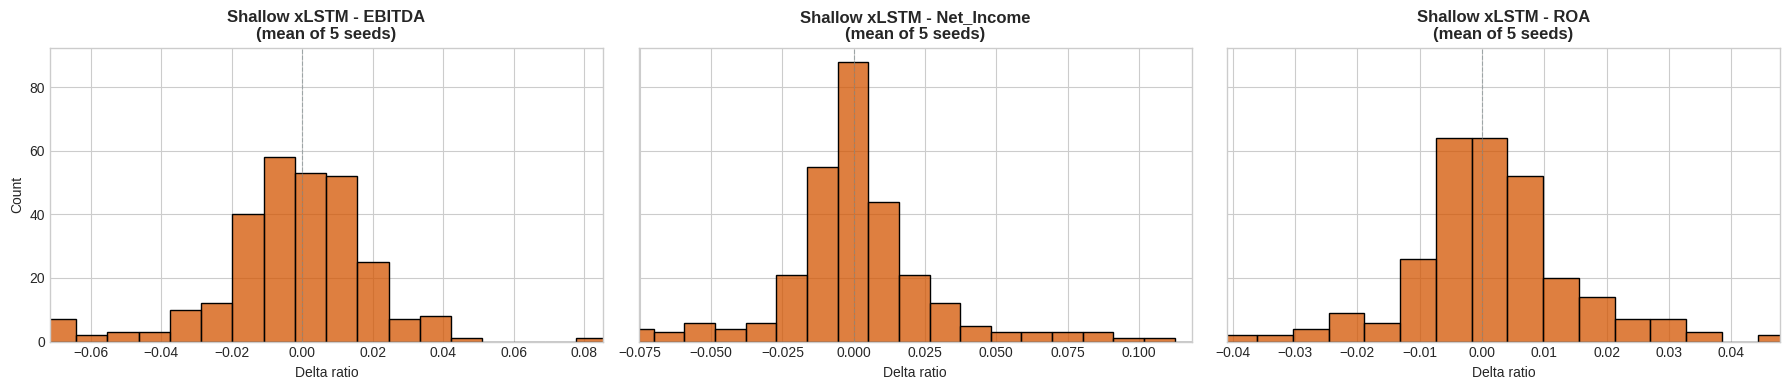

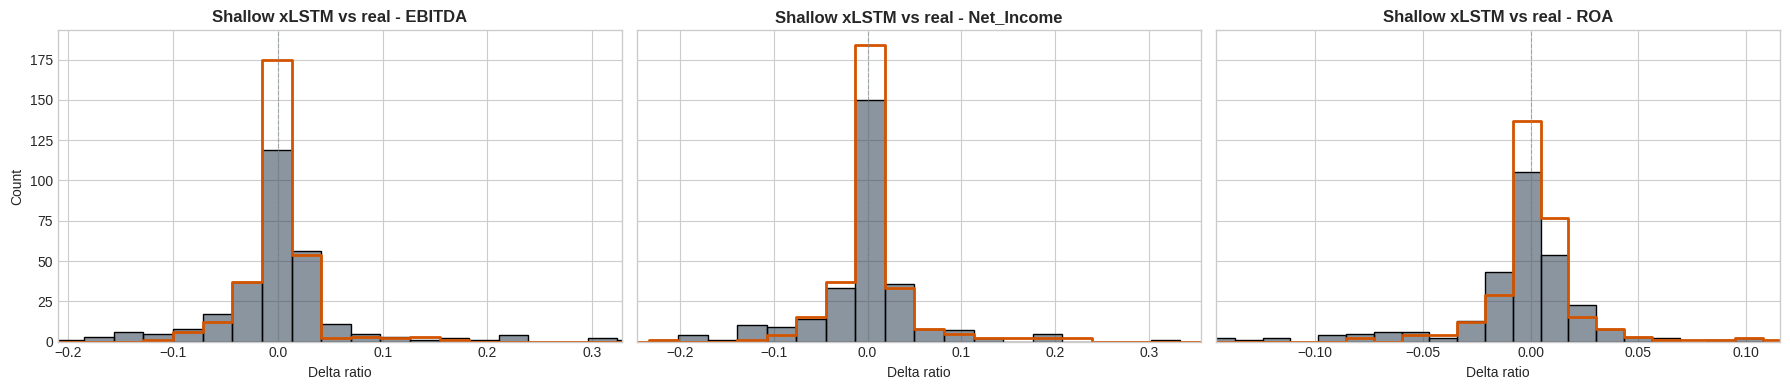

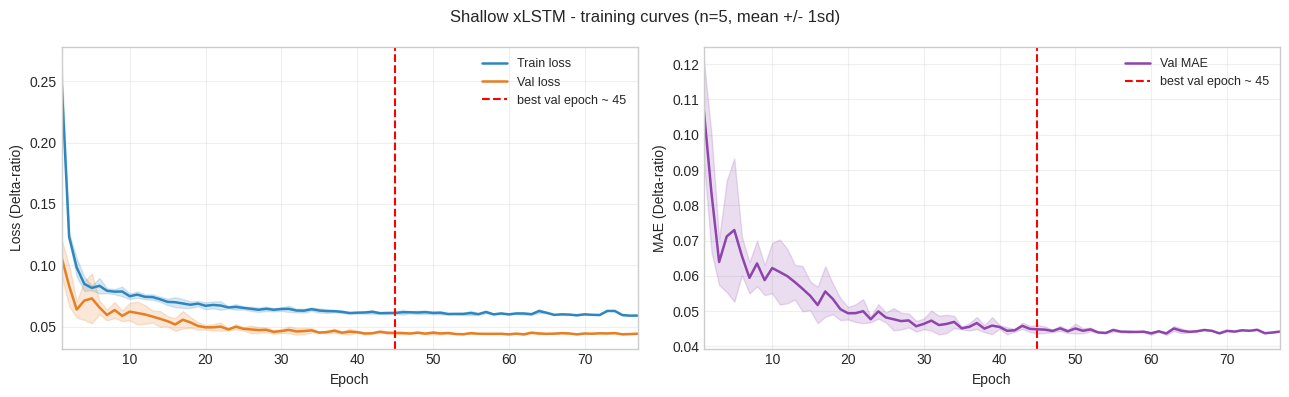

In [ ]:
params_A = study_A.best_trial.params
print(f"Shallow xLSTM final params: {params_A}")
def make_A(params):
    return make_shallow_mtl(train_data, val_data, params, selected_indices)
_t0 = _time.time()
results_A, test_res_A, preds_A, hist_A, raw_A = run_n_seeded_final(make_A, params_A, fwd_mtl, n_seeds=N_FINAL_SEEDS)
print(f"\nShallow xLSTM final test (n={N_FINAL_SEEDS} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_A[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_A, "Shallow xLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_A, "Shallow xLSTM")
plot_predictions_vs_targets(preds_A, "Shallow xLSTM")
plot_training_curves(hist_A, "Shallow xLSTM")


Stacked xLSTM final params: {'hidden_size': 128, 'lr': 0.0048553228141650995, 'batch_size': 16, 'weight_decay': 1.4414219304614172e-06, 'dropout': 0.25811340240847697, 'num_heads': 4, 'proj_factor': 2.0, 'num_blocks': 3, 'slstm_placement': 'last'}

Stacked xLSTM final test (n=5 seeds):
  EBITDA      : 0.0625 ± 0.0015
  Net_Income  : 0.0588 ± 0.0016
  ROA         : 0.0299 ± 0.0005
  Overall     : 0.0504 ± 0.0010
  Raw-scale test metrics Stacked xLSTM (Delta-ratio -> raw):
    EBITDA     : MAE 265819.3145 ± 19756.7017 | nMAE 33.3% ± 2.5% | R² 0.383 ± 0.097
    Net_Income : MAE 204103.7612 ± 25438.8953 | nMAE 60.6% ± 7.6% | R² -0.185 ± 0.286
    ROA        : MAE 0.0316 ± 0.0005 | nMAE 55.1% ± 0.8% | R² 0.421 ± 0.010
Time: 231.7 min


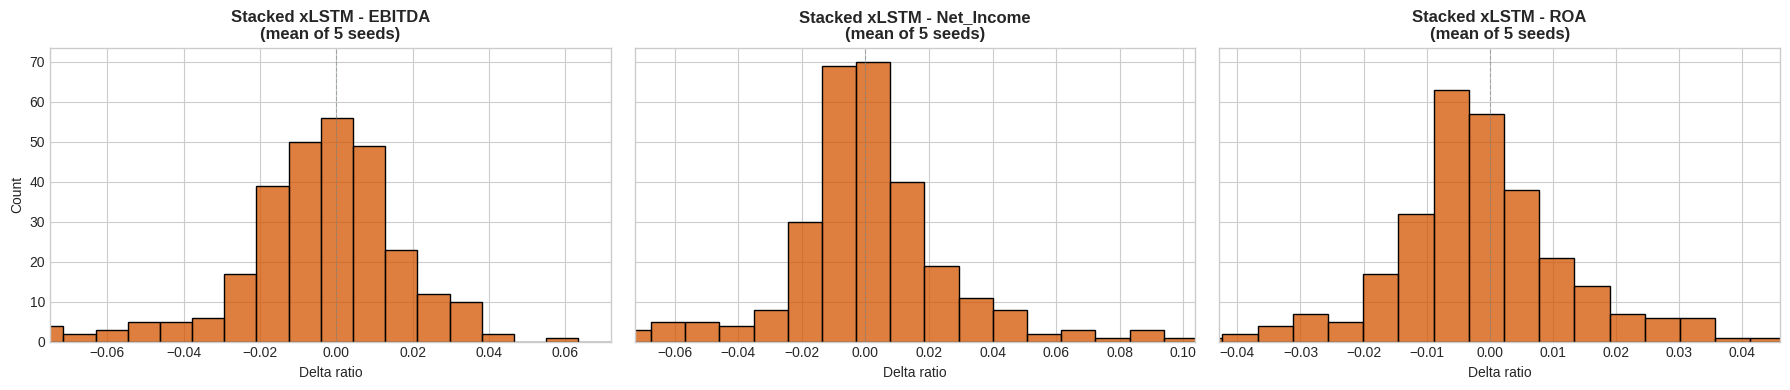

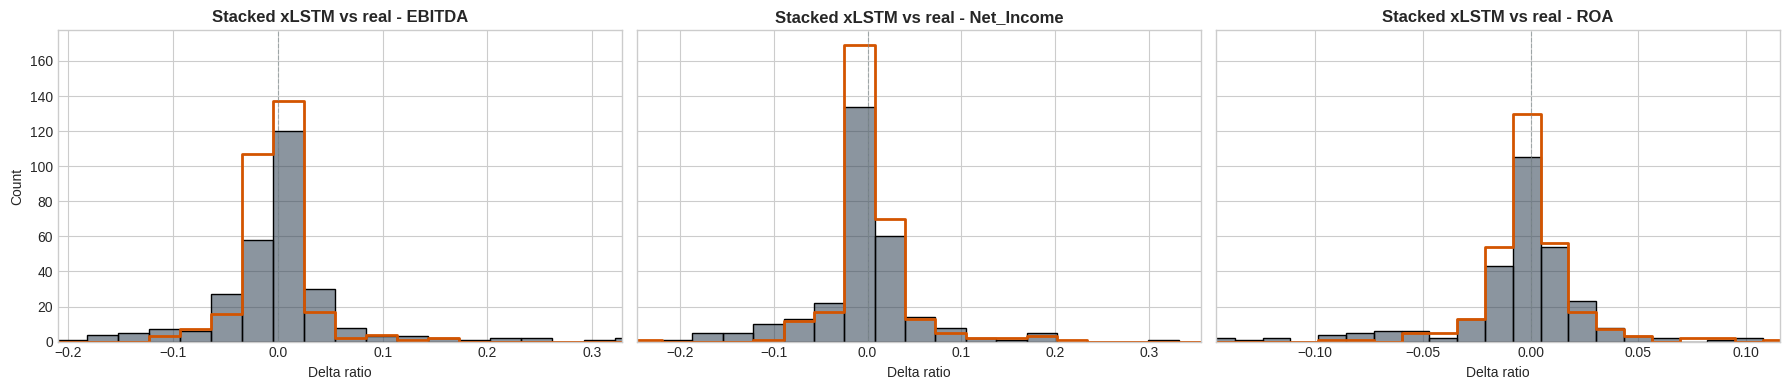

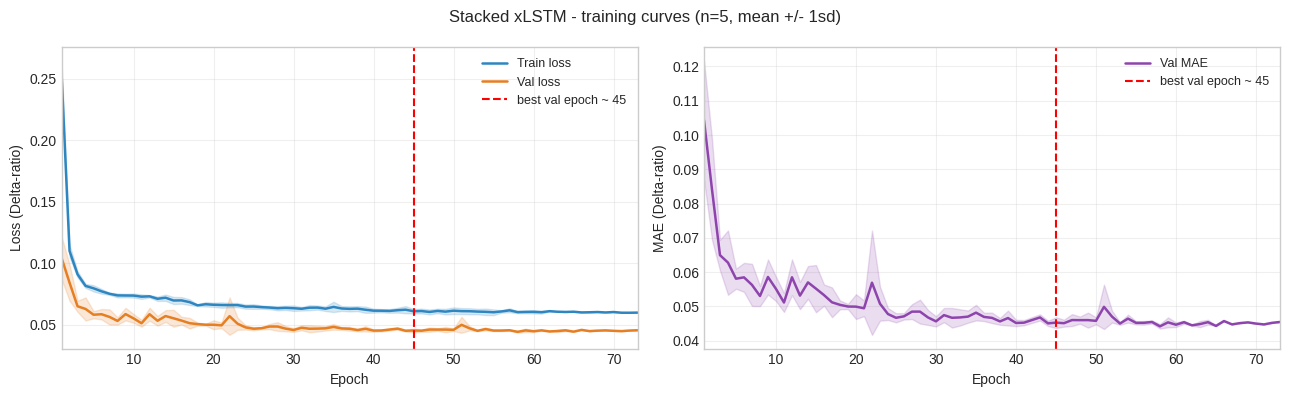

In [ ]:
params_B = study_B.best_trial.params
print(f"Stacked xLSTM final params: {params_B}")
def make_B(params):
    return make_stacked_mtl(train_data, val_data, params, selected_indices)
_t0 = _time.time()
results_B, test_res_B, preds_B, hist_B, raw_B = run_n_seeded_final(make_B, params_B, fwd_mtl, n_seeds=N_FINAL_SEEDS)
print(f"\nStacked xLSTM final test (n={N_FINAL_SEEDS} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_B[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_B, "Stacked xLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_B, "Stacked xLSTM")
plot_predictions_vs_targets(preds_B, "Stacked xLSTM")
plot_training_curves(hist_B, "Stacked xLSTM")


In [ ]:
def make_multifreq_gdp_loaders_for_fold(tr_df, va_df, params):
    """Model C loader builder: daily + monthly only.
    IT_GDP is folded into the monthly stream (forward-filled at monthly
    cadence); no separate quarterly MLP is used.
    """
    monthly_gdp_idx = monthly_indices + quarterly_indices
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    te_ds = MultiFreqDataset(te_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = MultiFreqLSTM_NoQuarterly(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_gdp_idx),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


MultiFreqLSTM final params: {'batch_size': 64, 'lr': 0.0005537423504723057, 'weight_decay': 1.0998221237042259e-06, 'dropout': 0.16788408358369425}

MultiFreqLSTM final test (n=5 seeds):
  EBITDA      : 0.0665 ± 0.0042
  Net_Income  : 0.0620 ± 0.0040
  ROA         : 0.0341 ± 0.0062
  Overall     : 0.0542 ± 0.0024
  Raw-scale test metrics MultiFreqLSTM (Delta-ratio -> raw):
    EBITDA     : MAE 277807.3236 ± 31259.4028 | nMAE 34.8% ± 3.9% | R² 0.336 ± 0.138
    Net_Income : MAE 212597.5614 ± 13948.2747 | nMAE 63.1% ± 4.1% | R² -0.209 ± 0.261
    ROA        : MAE 0.0357 ± 0.0062 | nMAE 62.2% ± 10.8% | R² 0.397 ± 0.044
Time: 8.8 min


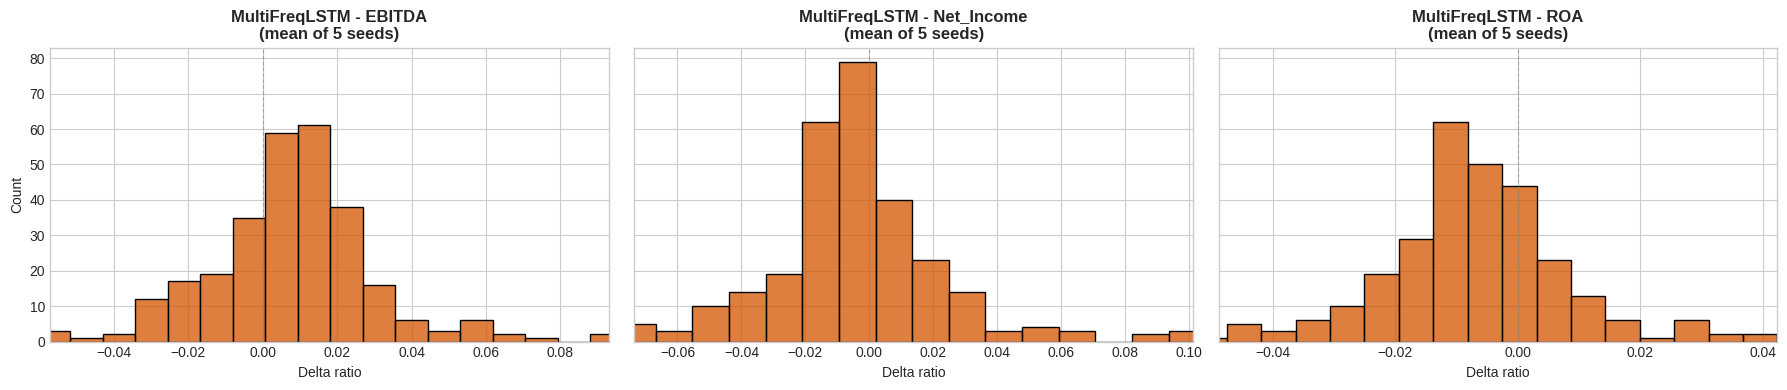

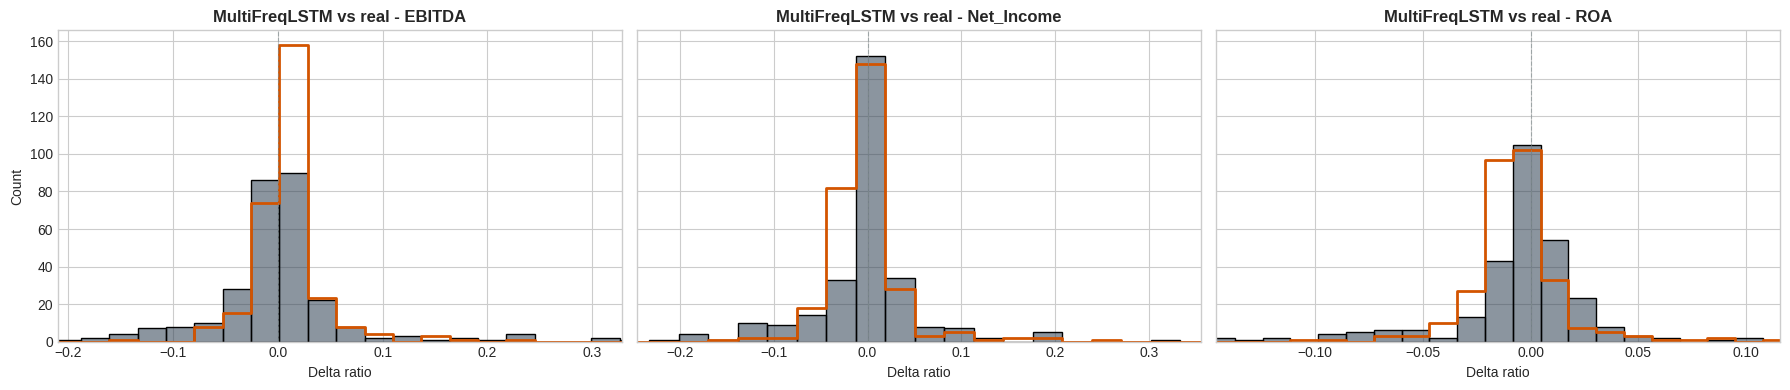

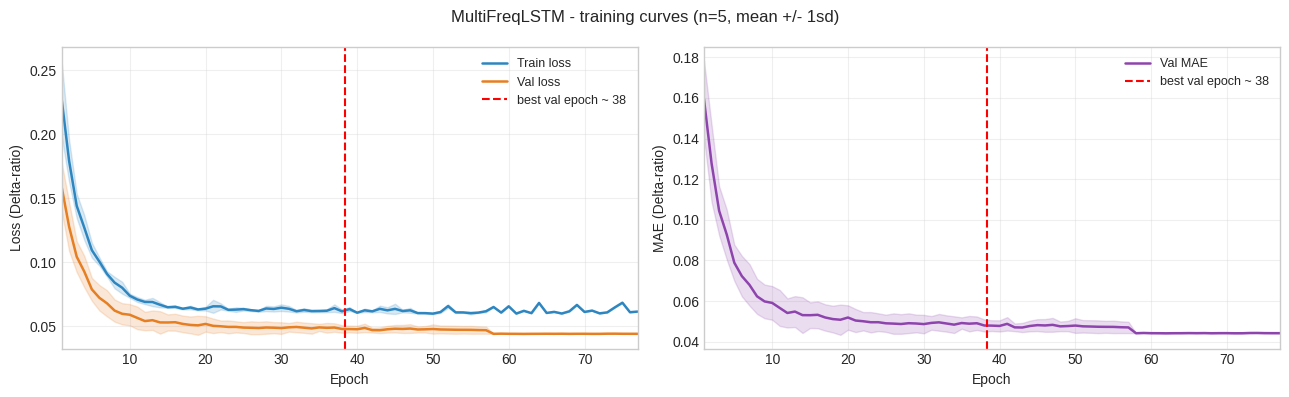

In [ ]:
def make_C(params):
    return make_multifreq_gdp_loaders_for_fold(train_data, val_data, params)

params_C = study_C.best_trial.params
print(f"MultiFreqLSTM final params: {params_C}")
N_FINAL_SEEDS_C = 5
_t0 = _time.time()
results_C, test_res_C, preds_C, hist_C, raw_C = run_n_seeded_final(make_C, params_C, fwd_mf, n_seeds=N_FINAL_SEEDS_C)
print(f"\nMultiFreqLSTM final test (n={N_FINAL_SEEDS_C} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_C[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_C, "MultiFreqLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_C, "MultiFreqLSTM")
plot_predictions_vs_targets(preds_C, "MultiFreqLSTM")
plot_training_curves(hist_C, "MultiFreqLSTM")


In [ ]:
def make_grouped_loaders_for_fold(tr_df, va_df, params):
    """Model D loader builder: K correlation-grouped daily streams.
    Grouping is recomputed from tr_df only (no leakage from val/test)."""
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    groups = compute_corr_groups(tr_mtl, selected_indices, k=GROUPED_K)
    group_sizes = [len(g) for g in groups]
    all_idx = [i for g in groups for i in g]
    scaler = make_robust_scaler(tr_mtl, all_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = GroupedDataset(tr_mtl_s, groups, scaler, None, n_daily=252)
    va_ds = GroupedDataset(va_mtl_s, groups, scaler, None, n_daily=252)
    te_ds = GroupedDataset(te_mtl_s, groups, scaler, None, n_daily=252)
    bs = params['batch_size']
    tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True,  collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = GroupedLSTM(
        group_sizes=group_sizes,
        hidden_sizes=params.get('hidden_sizes', GROUPED_HIDDEN_SIZES),
        n_layers=params.get('n_layers', GROUPED_N_LAYERS),
        n_static=STATIC_DIM_IMP,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


GroupedLSTM final params: {'batch_size': 64, 'lr': 0.00450725961161414, 'weight_decay': 7.841453642221816e-06, 'dropout': 0.10422355878323203}

GroupedLSTM final test (n=5 seeds):
  EBITDA      : 0.0629 ± 0.0005
  Net_Income  : 0.0588 ± 0.0003
  ROA         : 0.0297 ± 0.0002
  Overall     : 0.0505 ± 0.0002
  Raw-scale test metrics GroupedLSTM (Delta-ratio -> raw):
    EBITDA     : MAE 255476.7990 ± 10322.7771 | nMAE 32.0% ± 1.3% | R² 0.395 ± 0.044
    Net_Income : MAE 201505.4546 ± 5857.8209 | nMAE 59.8% ± 1.7% | R² -0.263 ± 0.099
    ROA        : MAE 0.0313 ± 0.0002 | nMAE 54.7% ± 0.3% | R² 0.442 ± 0.013
Time: 12.7 min


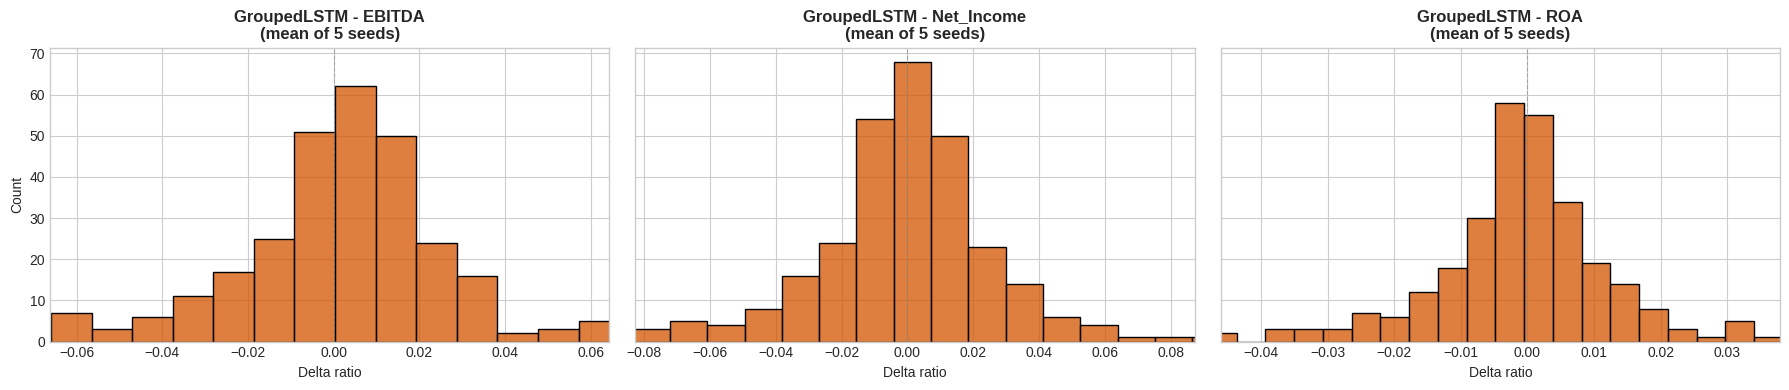

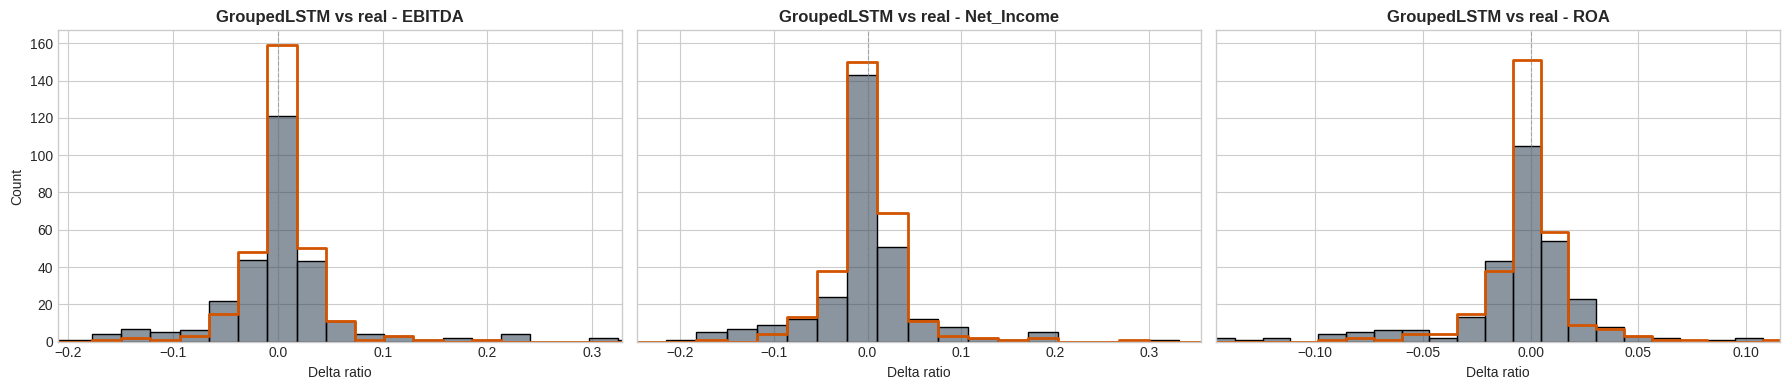

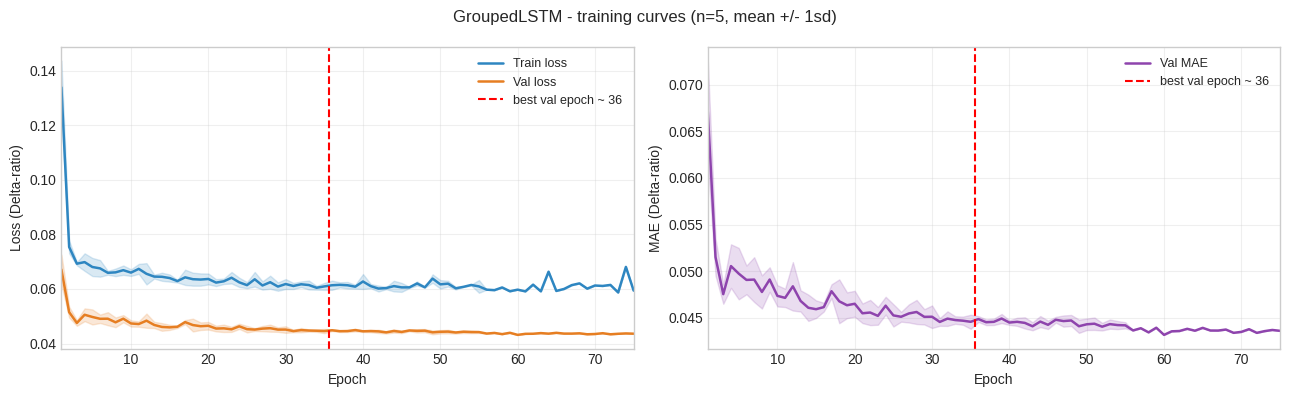

In [ ]:
def make_D(params):
    return make_grouped_loaders_for_fold(train_data, val_data, params)

params_D = study_D.best_trial.params
print(f"GroupedLSTM final params: {params_D}")
N_FINAL_SEEDS_D = 5
_t0 = _time.time()
results_D, test_res_D, preds_D, hist_D, raw_D = run_n_seeded_final(make_D, params_D, fwd_grouped, n_seeds=N_FINAL_SEEDS_D)
print(f"\nGroupedLSTM final test (n={N_FINAL_SEEDS_D} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_D[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_D, "GroupedLSTM (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_D, "GroupedLSTM")
plot_predictions_vs_targets(preds_D, "GroupedLSTM")
plot_training_curves(hist_D, "GroupedLSTM")


In [ ]:
def make_multifreq_ds_loaders_for_fold(tr_df, va_df, params):
    """Model E loader builder: same data pipeline as Model C (daily + monthly
    only, IT_GDP folded into the monthly stream); the model is MultiFreqLSTM_DS."""
    monthly_gdp_idx = monthly_indices + quarterly_indices
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    te_ds = MultiFreqDataset(te_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = MultiFreqLSTM_DS(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_gdp_idx),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


MultiFreqLSTM-DS final params: {'batch_size': 16, 'lr': 0.0013339003969520073, 'weight_decay': 8.154145546759695e-06, 'dropout': 0.4453009772111255, 'aux_weight': 0.0}

MultiFreqLSTM-DS final test (n=5 seeds):
  EBITDA      : 0.0625 ± 0.0015
  Net_Income  : 0.0621 ± 0.0022
  ROA         : 0.0315 ± 0.0009
  Overall     : 0.0520 ± 0.0012
  Raw-scale test metrics MultiFreqLSTM-DS (Delta-ratio -> raw):
    EBITDA     : MAE 272084.3172 ± 23149.7006 | nMAE 34.1% ± 2.9% | R² 0.324 ± 0.116
    Net_Income : MAE 215714.4070 ± 7887.4921 | nMAE 64.1% ± 2.3% | R² -0.256 ± 0.084
    ROA        : MAE 0.0331 ± 0.0009 | nMAE 57.7% ± 1.5% | R² 0.411 ± 0.011
Time: 9.2 min


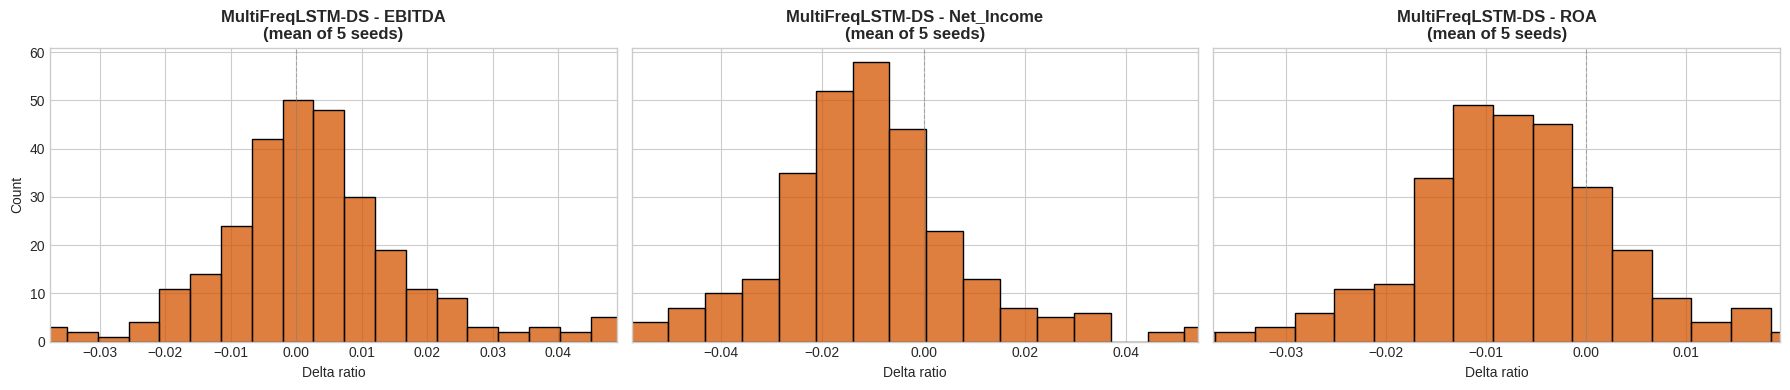

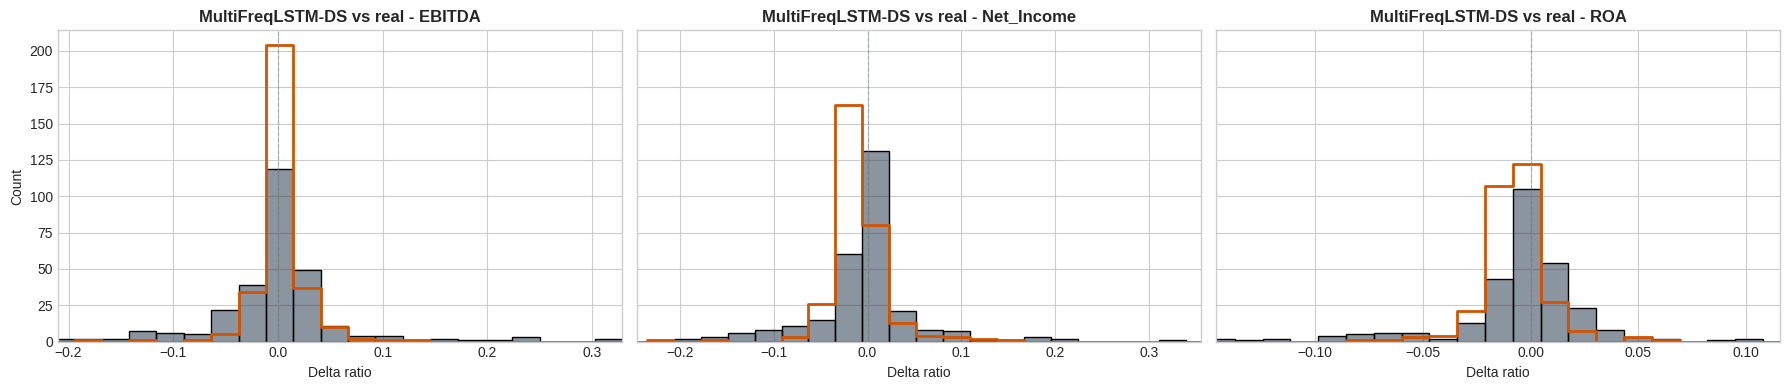

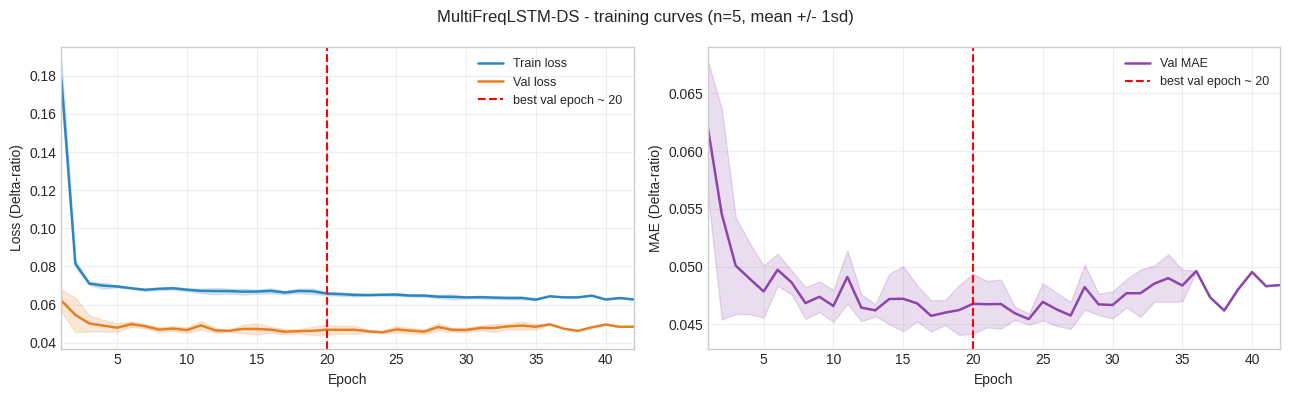

In [ ]:
def make_E(params):
    return make_multifreq_ds_loaders_for_fold(train_data, val_data, params)

if 'study_E' not in globals():
    raise RuntimeError(
        "Model E Optuna results are missing. Run the Model E Optuna cell first."
    )
params_E = study_E.best_trial.params
print(f"MultiFreqLSTM-DS final params: {params_E}")
N_FINAL_SEEDS_E = 5
_t0 = _time.time()
results_E, test_res_E, preds_E, hist_E, raw_E = run_n_seeded_final(
    make_E, params_E, fwd_mf, n_seeds=N_FINAL_SEEDS_E,
    loss_fn=make_ds_loss_fn(params_E.get('aux_weight', 0.0)),
)
print(f"\nMultiFreqLSTM-DS final test (n={N_FINAL_SEEDS_E} seeds):")
for k in PREDICTION_TARGETS + ["Overall"]:
    vals = results_E[k]
    print(f"  {k:12s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")
print_raw_mae(raw_E, "MultiFreqLSTM-DS (Delta-ratio -> raw)")
print(f"Time: {(_time.time()-_t0)/60:.1f} min")

plot_prediction_distributions(preds_E, "MultiFreqLSTM-DS")
plot_predictions_vs_targets(preds_E, "MultiFreqLSTM-DS")
plot_training_curves(hist_E, "MultiFreqLSTM-DS")


## Per-Fold Evaluation

In [ ]:
def run_per_fold_final(make_model_fn, params, adapt,
                       n_seeds=3, collect_preds=True, loss_fn=None):
    """For each fold, train `n_seeds` models with the given params and evaluate
    on that fold's held-out year. `make_model_fn(params, tr_df, va_df)` builds
    loaders for the fold; `adapt` handles the batch layout. `loss_fn` is
    passed through to train_and_eval (e.g. make_ds_loss_fn).
    Returns per_fold[fold_idx] = {
        'val_year', 'seed_maes', 'preds_untrained', 'preds_trained',
        'targets', 'masks', 'histories',
    }"""
    per_fold = {}
    for fold_idx, (tr_df, va_df, val_year, fi) in enumerate(folds):
        seed_maes = []
        preds_u_dict = {}
        preds_t_dict = {}
        targets_arr = None
        masks_arr = None
        histories = {}
        raw_trained = {t: {"mae": [], "nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS}
        raw_untrained = {t: {"mae": [], "nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS}
        for s in range(n_seeds):
            np.random.seed(SEED + s); torch.manual_seed(SEED + s)
            if collect_preds:
                # Untrained baseline predictions
                model_u, _, _, te_loader_u = make_model_fn(params, tr_df, va_df)
                yp_u, _, _ = collect_predictions(model_u, te_loader_u, adapt)
                yp_u_aligned = collect_predictions_aligned(model_u, te_loader_u, adapt)
                _rm_u = raw_mae_delta_ratio(yp_u_aligned, test_meta)
                for _k, _v in _rm_u.items():
                    raw_untrained[_k]["mae"].append(_v["mae"])
                    raw_untrained[_k]["nmae_pct"].append(_v["nmae_pct"])
                    raw_untrained[_k]["r2"].append(_v["r2"])
                del model_u
            # Train
            np.random.seed(SEED + s); torch.manual_seed(SEED + s)
            model, tr_loader, va_loader, te_loader = make_model_fn(params, tr_df, va_df)
            optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
            model, _, _, history = train_and_eval(
                model, tr_loader, va_loader, optimizer, adapt, collect_history=True,
                loss_fn=loss_fn)
            seed_maes.append(evaluate_loader(model, te_loader, adapt))
            yp_t_aligned = collect_predictions_aligned(model, te_loader, adapt)
            _rm_t = raw_mae_delta_ratio(yp_t_aligned, test_meta)
            for _k, _v in _rm_t.items():
                raw_trained[_k]["mae"].append(_v["mae"])
                raw_trained[_k]["nmae_pct"].append(_v["nmae_pct"])
                raw_trained[_k]["r2"].append(_v["r2"])
            if collect_preds:
                yp_t, yt_chk, mask_chk = collect_predictions(model, te_loader, adapt)
                targets_arr = yt_chk
                masks_arr = mask_chk
                preds_u_dict[s] = yp_u
                preds_t_dict[s] = yp_t
            histories[s] = history
            del model
        per_fold[fold_idx] = {
            'val_year': int(val_year),
            'seed_maes': seed_maes,
            'preds_untrained': preds_u_dict,
            'preds_trained': preds_t_dict,
            'targets': targets_arr,
            'masks': masks_arr,
            'histories': histories,
            'raw_trained': raw_trained,
            'raw_untrained': raw_untrained,
        }
        maes_overall = [m['Overall'] for m in seed_maes]
        print(f"  Fold {fi} (val={val_year}): "
              f"Overall MAE = {np.mean(maes_overall):.4f} ± {np.std(maes_overall):.4f}")
        print_fold_raw(raw_trained, 'trained')
        if collect_preds:
            print_fold_raw(raw_untrained, 'untrained')
    print('  Cross-fold raw-scale (mean of seeds per fold, then across folds):')
    print_cross_fold_raw([per_fold[i]['raw_trained'] for i in sorted(per_fold)], 'trained')
    if collect_preds:
        print_cross_fold_raw([per_fold[i]['raw_untrained'] for i in sorted(per_fold)], 'untrained')
    return per_fold


In [ ]:
def make_A_for_fold(params, tr_df, va_df):
    return make_shallow_mtl(tr_df, va_df, params, selected_indices)

def make_B_for_fold(params, tr_df, va_df):
    return make_stacked_mtl(tr_df, va_df, params, selected_indices)


Shallow xLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.0608 ± 0.0072
    trained   : nMAE% EBITDA 32.9% | Net_Income 63.9% | ROA 64.4%
                R2   EBITDA 0.61 | Net_Income 0.15 | ROA 0.37
                MAE  EBITDA 262182.1045 | Net_Income 215119.4020 | ROA 0.0370
    untrained : nMAE% EBITDA 270.4% | Net_Income 281.3% | ROA 609.6%
                R2   EBITDA -7.93 | Net_Income -8.24 | ROA -20.78
                MAE  EBITDA 2155327.4496 | Net_Income 947180.9913 | ROA 0.3496
  Fold 2 (val=2020): Overall MAE = 0.0670 ± 0.0020
    trained   : nMAE% EBITDA 33.9% | Net_Income 70.2% | ROA 87.1%
                R2   EBITDA 0.52 | Net_Income 0.25 | ROA 0.24
                MAE  EBITDA 270252.9148 | Net_Income 236547.2374 | ROA 0.0500
    untrained : nMAE% EBITDA 291.4% | Net_Income 281.3% | ROA 576.0%
                R2   EBITDA -9.60 | Net_Income -7.78 | ROA -18.81
                MAE  EBITDA 2322938.8232 | Net_Income 947080.2120 | ROA 0.3303
  Fold 3 (val=2021): Overall 

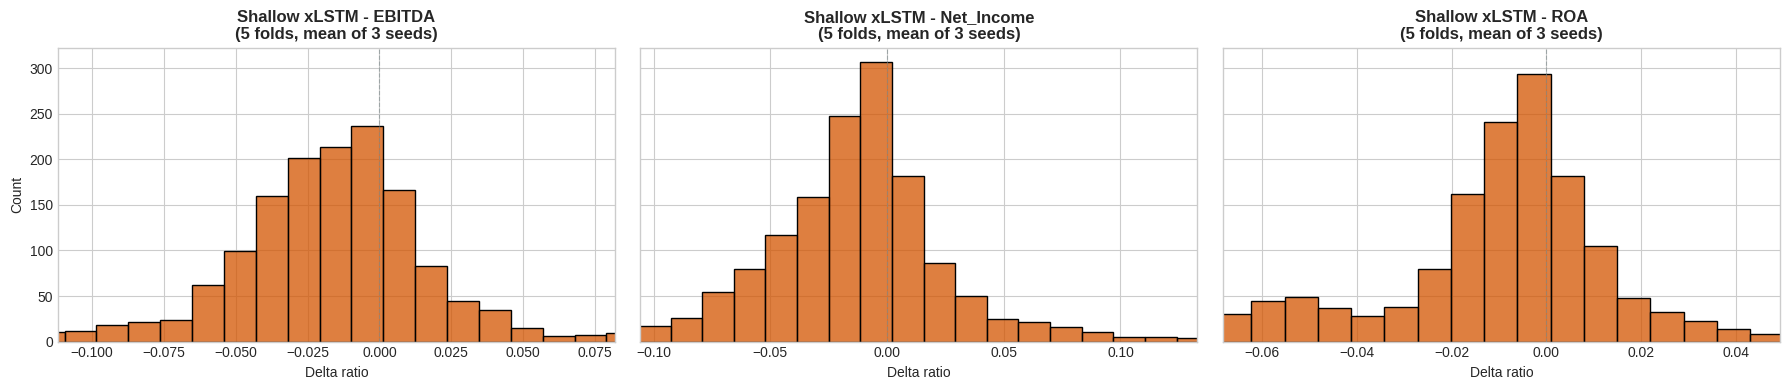

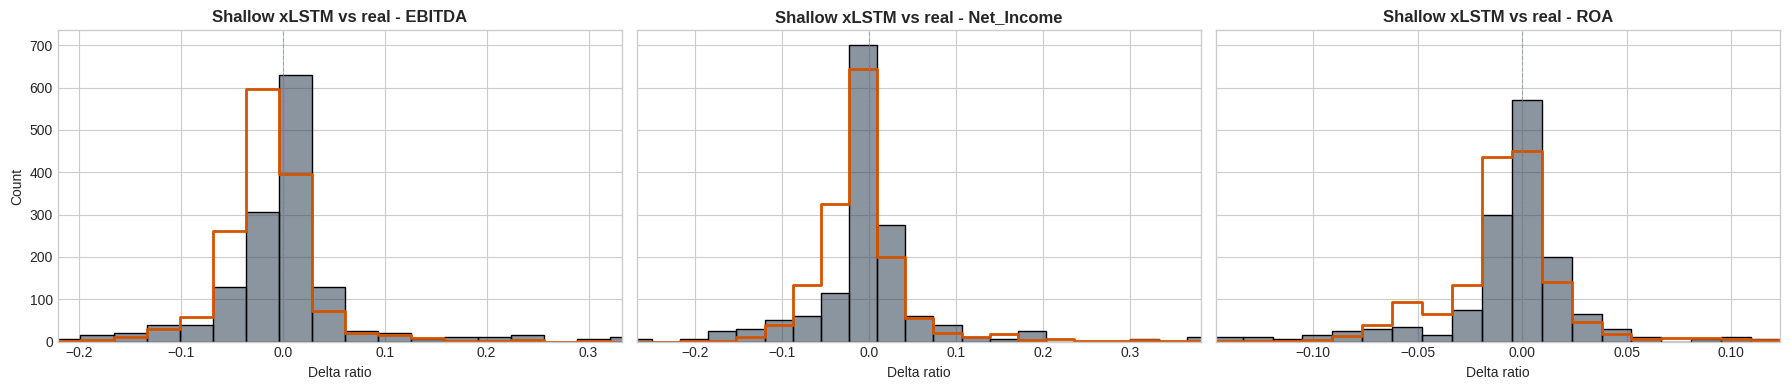

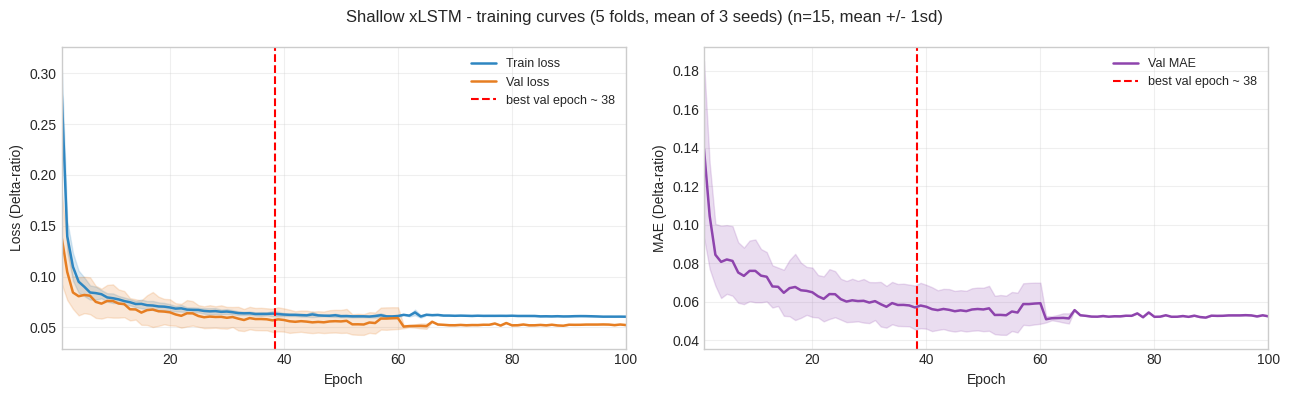

In [ ]:
print("Shallow xLSTM per-fold test:")
_t0 = _time.time()
per_fold_A = run_per_fold_final(make_A_for_fold, params_A, fwd_mtl, n_seeds=3)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_A, "Shallow xLSTM")
plot_predictions_vs_targets_agg(per_fold_A, "Shallow xLSTM")
plot_training_curves_agg(per_fold_A, "Shallow xLSTM")


Stacked xLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.0723 ± 0.0000
    trained   : nMAE% EBITDA 45.1% | Net_Income 78.5% | ROA 80.5%
                R2   EBITDA 0.73 | Net_Income -0.34 | ROA 0.31
                MAE  EBITDA 359734.3713 | Net_Income 264358.9919 | ROA 0.0462
    untrained : nMAE% EBITDA 126.1% | Net_Income 1048.3% | ROA 341.1%
                R2   EBITDA -1.07 | Net_Income -85.44 | ROA -6.00
                MAE  EBITDA 1005161.5941 | Net_Income 3529900.0118 | ROA 0.1956
  Fold 2 (val=2020): Overall MAE = 0.0516 ± 0.0000
    trained   : nMAE% EBITDA 32.1% | Net_Income 63.1% | ROA 56.9%
                R2   EBITDA 0.41 | Net_Income -0.15 | ROA 0.42
                MAE  EBITDA 256214.3321 | Net_Income 212316.0168 | ROA 0.0327
    untrained : nMAE% EBITDA 120.9% | Net_Income 1092.4% | ROA 445.4%
                R2   EBITDA -0.65 | Net_Income -91.77 | ROA -9.70
                MAE  EBITDA 963741.1434 | Net_Income 3678459.3168 | ROA 0.2554
  Fold 3 (val=2021): Ove

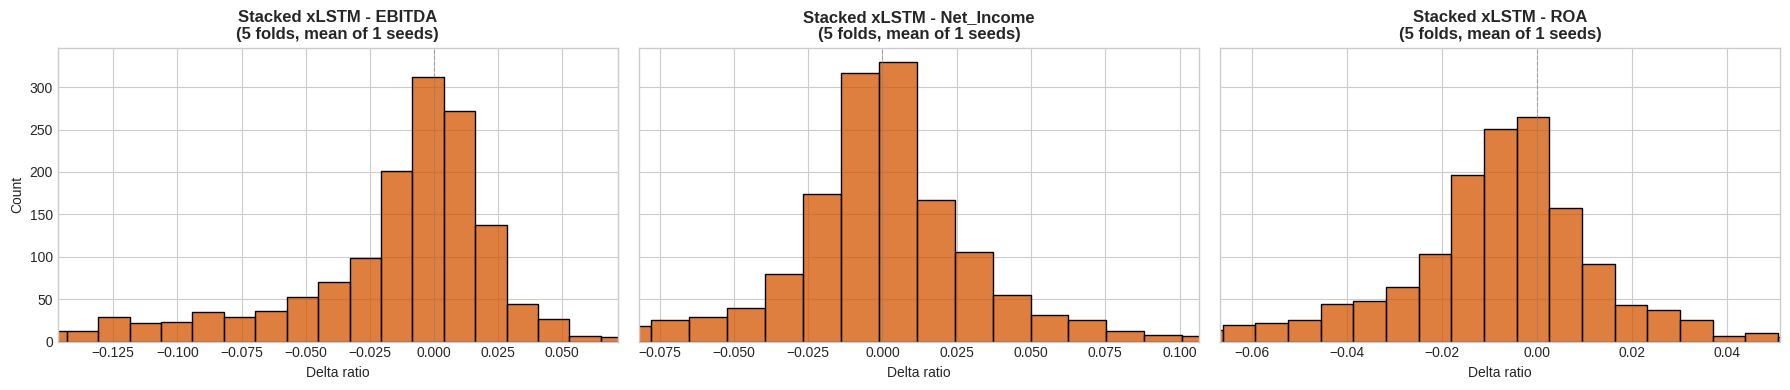

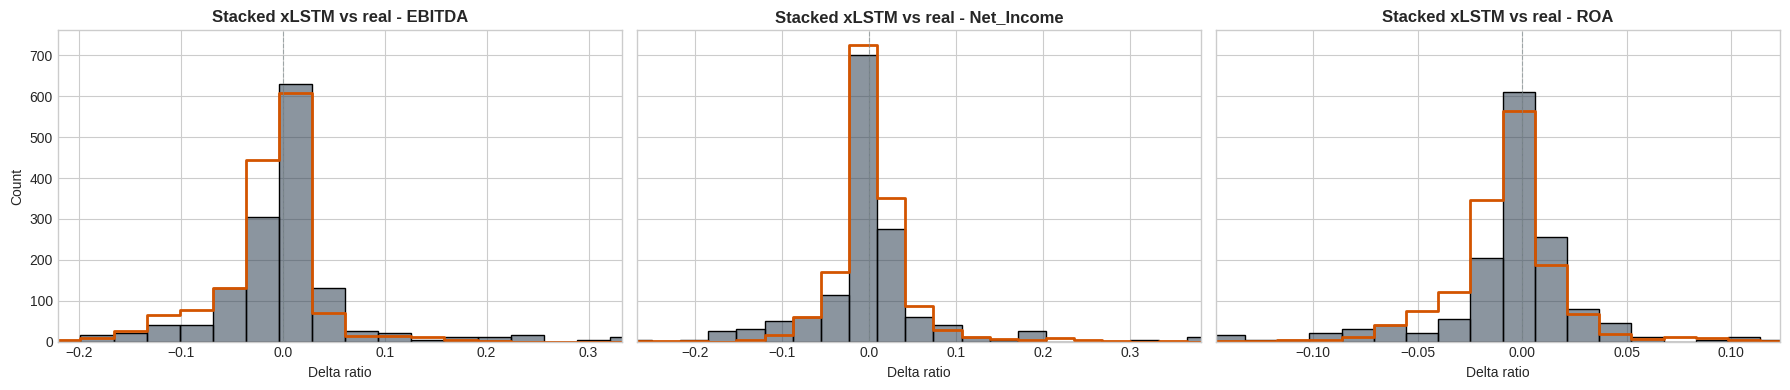

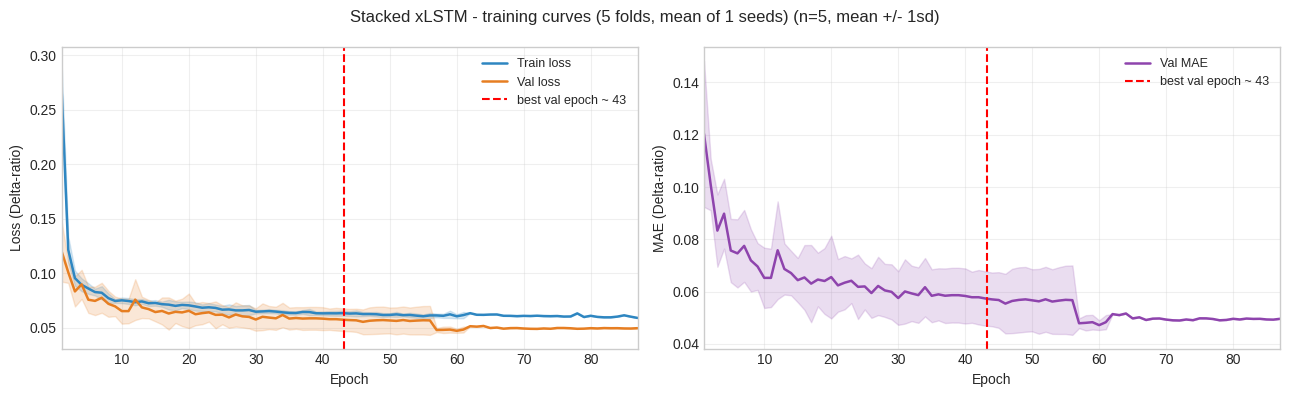

In [ ]:
print("Stacked xLSTM per-fold test:")
_t0 = _time.time()
per_fold_B = run_per_fold_final(make_B_for_fold, params_B, fwd_mtl, n_seeds=1)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_B, "Stacked xLSTM")
plot_predictions_vs_targets_agg(per_fold_B, "Stacked xLSTM")
plot_training_curves_agg(per_fold_B, "Stacked xLSTM")


In [ ]:
def make_multifreq_gdp_loaders_for_fold(tr_df, va_df, params):
    """Model C loader builder: daily + monthly only.
    IT_GDP is folded into the monthly stream (forward-filled at monthly
    cadence); no separate quarterly MLP is used.
    """
    monthly_gdp_idx = monthly_indices + quarterly_indices
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    te_ds = MultiFreqDataset(te_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = MultiFreqLSTM_NoQuarterly(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_gdp_idx),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


MultiFreqLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.0754 ± 0.0082
    trained   : nMAE% EBITDA 41.4% | Net_Income 102.3% | ROA 85.2%
                R2   EBITDA 0.35 | Net_Income -0.81 | ROA 0.24
                MAE  EBITDA 330164.4438 | Net_Income 344442.5010 | ROA 0.0489
    untrained : nMAE% EBITDA 87.1% | Net_Income 366.4% | ROA 331.0%
                R2   EBITDA -0.60 | Net_Income -11.83 | ROA -9.79
                MAE  EBITDA 694129.7983 | Net_Income 1233895.9217 | ROA 0.1898
  Fold 2 (val=2020): Overall MAE = 0.0702 ± 0.0127
    trained   : nMAE% EBITDA 42.1% | Net_Income 80.5% | ROA 81.1%
                R2   EBITDA 0.37 | Net_Income -0.30 | ROA 0.28
                MAE  EBITDA 335570.4371 | Net_Income 270960.6117 | ROA 0.0465
    untrained : nMAE% EBITDA 91.0% | Net_Income 357.6% | ROA 329.4%
                R2   EBITDA -0.69 | Net_Income -11.49 | ROA -10.35
                MAE  EBITDA 725606.5103 | Net_Income 1204286.1483 | ROA 0.1889
  Fold 3 (val=2021): Overal

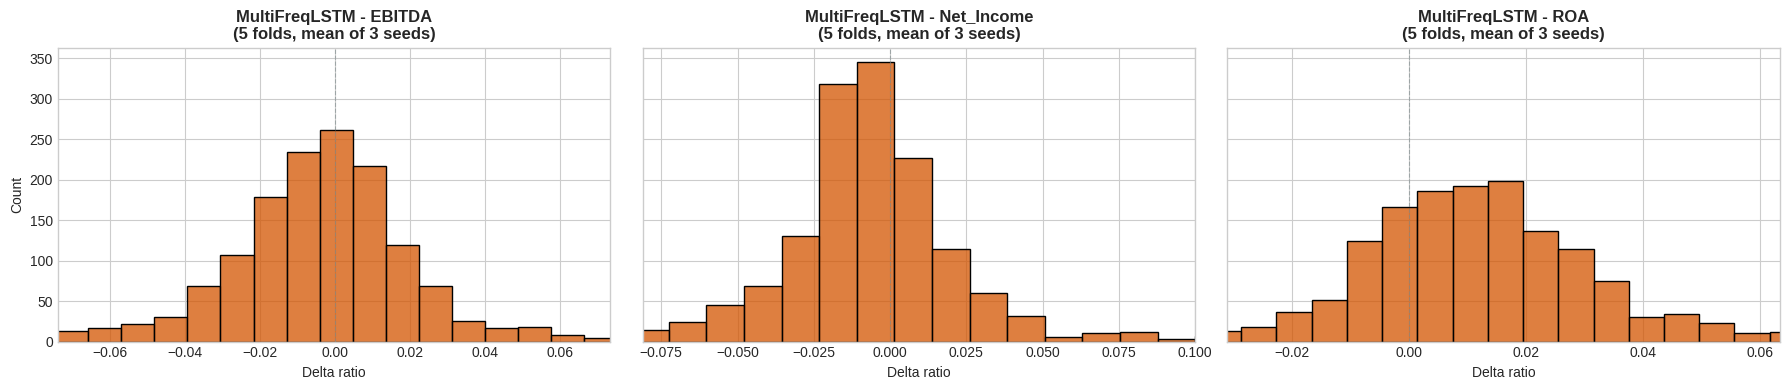

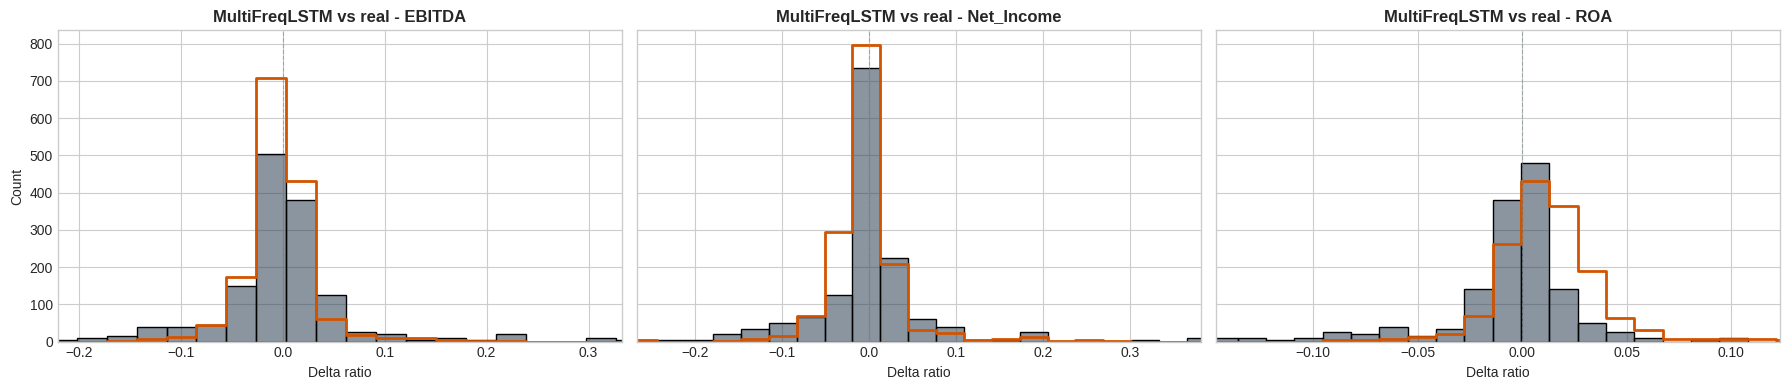

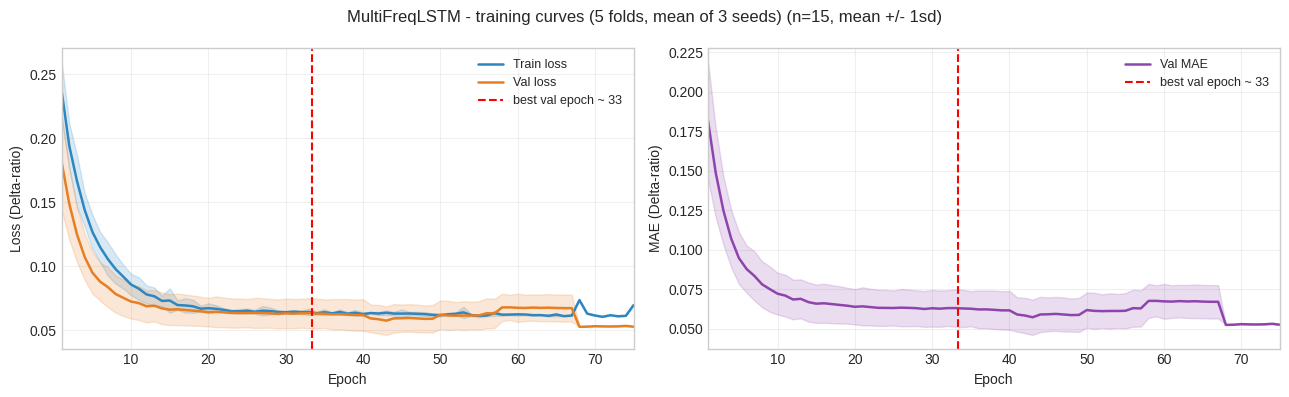

In [ ]:
def make_C_for_fold(params, tr_df, va_df):
    return make_multifreq_gdp_loaders_for_fold(tr_df, va_df, params)

if not params_C:
    raise RuntimeError(
        "Model C Optuna results are empty. Run the Model C Optuna cell and fill"
        "_OPTUNA_RESULTS_C before running this cell."
    )
print("MultiFreqLSTM per-fold test:")
_t0 = _time.time()
per_fold_C = run_per_fold_final(make_C_for_fold, params_C, fwd_mf, n_seeds=3)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_C, "MultiFreqLSTM")
plot_predictions_vs_targets_agg(per_fold_C, "MultiFreqLSTM")
plot_training_curves_agg(per_fold_C, "MultiFreqLSTM")


In [ ]:
def make_grouped_loaders_for_fold(tr_df, va_df, params):
    """Model D loader builder: K correlation-grouped daily streams.
    Grouping is recomputed from tr_df only (no leakage from val/test)."""
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    groups = compute_corr_groups(tr_mtl, selected_indices, k=GROUPED_K)
    group_sizes = [len(g) for g in groups]
    all_idx = [i for g in groups for i in g]
    scaler = make_robust_scaler(tr_mtl, all_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = GroupedDataset(tr_mtl_s, groups, scaler, None, n_daily=252)
    va_ds = GroupedDataset(va_mtl_s, groups, scaler, None, n_daily=252)
    te_ds = GroupedDataset(te_mtl_s, groups, scaler, None, n_daily=252)
    bs = params['batch_size']
    tr_loader = DataLoader(tr_ds, batch_size=bs, shuffle=True,  collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=bs, shuffle=False, collate_fn=collate_fn_grouped,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = GroupedLSTM(
        group_sizes=group_sizes,
        hidden_sizes=params.get('hidden_sizes', GROUPED_HIDDEN_SIZES),
        n_layers=params.get('n_layers', GROUPED_N_LAYERS),
        n_static=STATIC_DIM_IMP,
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


GroupedLSTM per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.0515 ± 0.0003
    trained   : nMAE% EBITDA 30.9% | Net_Income 63.4% | ROA 55.1%
                R2   EBITDA 0.47 | Net_Income -0.42 | ROA 0.44
                MAE  EBITDA 246291.7945 | Net_Income 213620.9373 | ROA 0.0316
    untrained : nMAE% EBITDA 103.7% | Net_Income 292.7% | ROA 217.8%
                R2   EBITDA -2.68 | Net_Income -14.75 | ROA -3.02
                MAE  EBITDA 826467.9244 | Net_Income 985697.8553 | ROA 0.1249
  Fold 2 (val=2020): Overall MAE = 0.0544 ± 0.0021
    trained   : nMAE% EBITDA 31.0% | Net_Income 62.4% | ROA 62.2%
                R2   EBITDA 0.49 | Net_Income 0.06 | ROA 0.42
                MAE  EBITDA 246921.0949 | Net_Income 210012.4564 | ROA 0.0357
    untrained : nMAE% EBITDA 106.3% | Net_Income 294.6% | ROA 223.8%
                R2   EBITDA -2.86 | Net_Income -14.76 | ROA -3.26
                MAE  EBITDA 847400.9050 | Net_Income 991848.3413 | ROA 0.1283
  Fold 3 (val=2021): Overall MAE

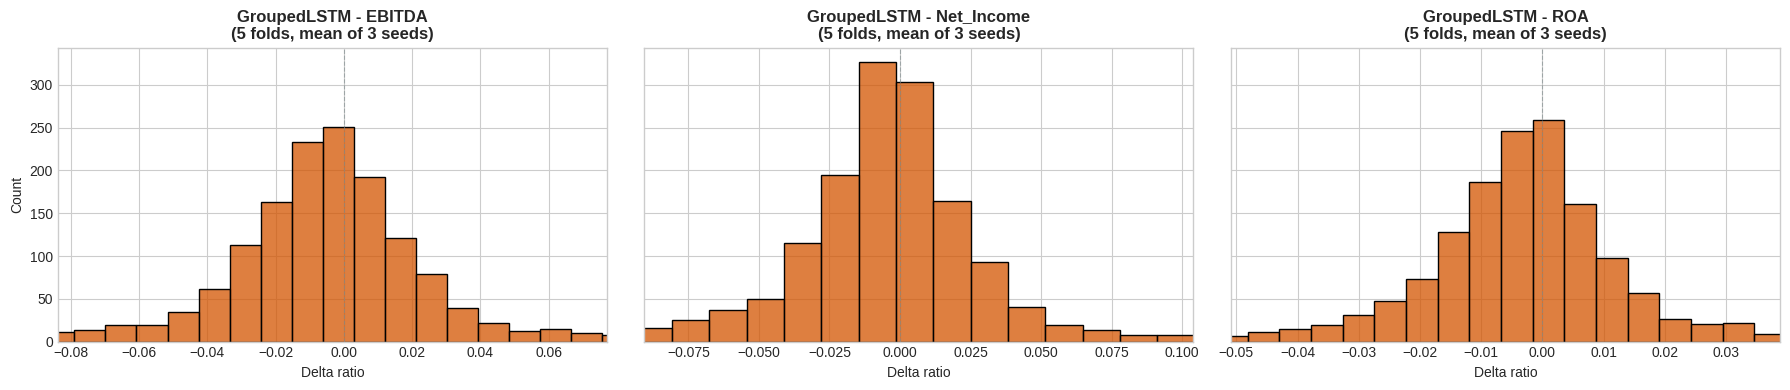

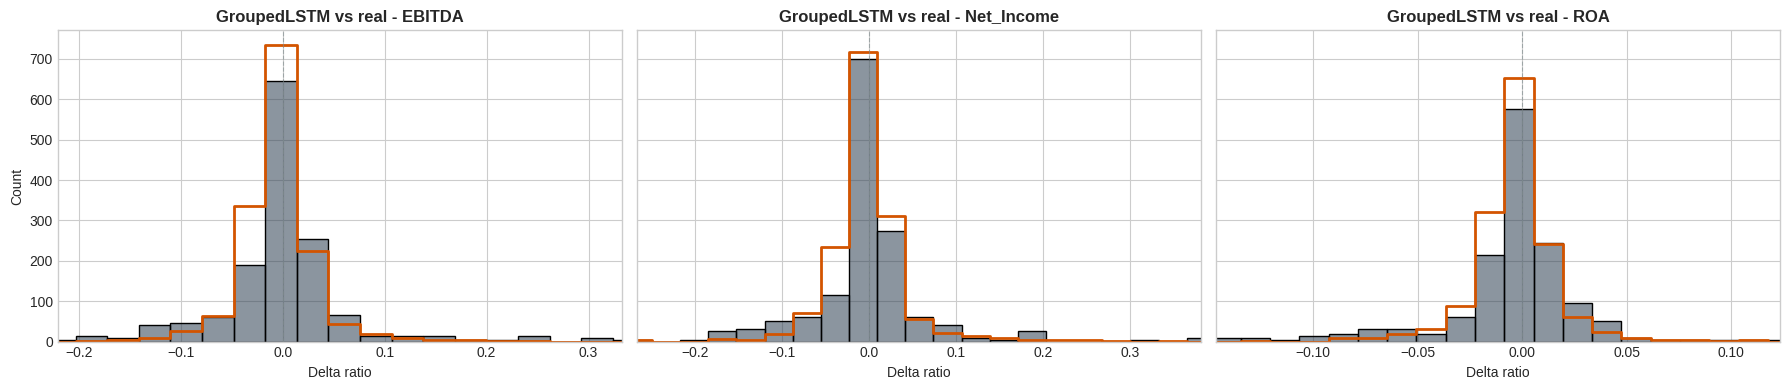

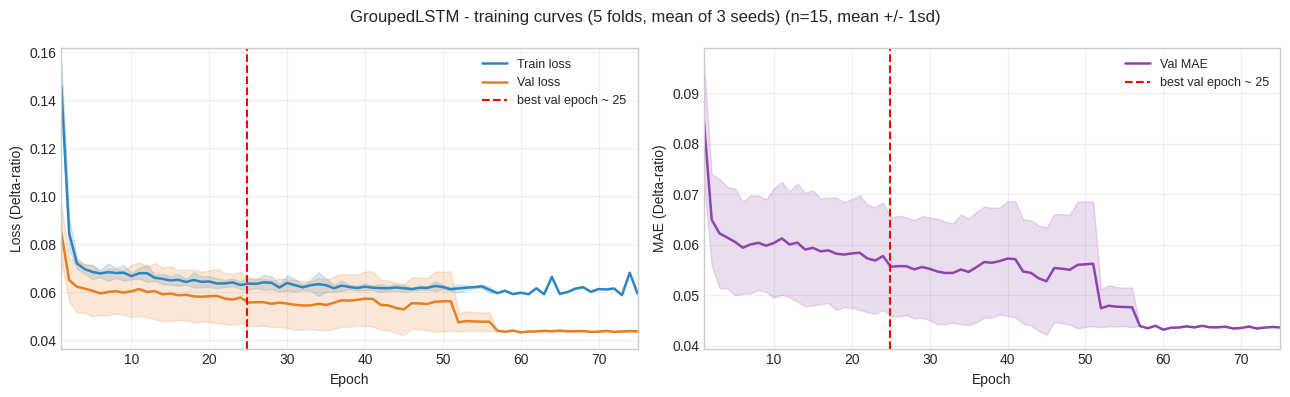

In [ ]:
def make_D_for_fold(params, tr_df, va_df):
    return make_grouped_loaders_for_fold(tr_df, va_df, params)

if not params_D:
    raise RuntimeError(
        "Model D Optuna results are empty. Run the Model D Optuna cell and fill"
        "_OPTUNA_RESULTS_D before running this cell."
    )
print("GroupedLSTM per-fold test:")
_t0 = _time.time()
per_fold_D = run_per_fold_final(make_D_for_fold, params_D, fwd_grouped, n_seeds=3)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_D, "GroupedLSTM")
plot_predictions_vs_targets_agg(per_fold_D, "GroupedLSTM")
plot_training_curves_agg(per_fold_D, "GroupedLSTM")


In [ ]:
def make_multifreq_ds_loaders_for_fold(tr_df, va_df, params):
    """Model E loader builder: same data pipeline as Model C (daily + monthly
    only, IT_GDP folded into the monthly stream); the model is MultiFreqLSTM_DS."""
    monthly_gdp_idx = monthly_indices + quarterly_indices
    tr_mtl = extract_mtl_df(tr_df)
    va_mtl = extract_mtl_df(va_df)
    te_mtl = extract_mtl_df(test_data)
    daily_sc = make_robust_scaler(tr_mtl, daily_indices)
    monthly_sc = make_robust_scaler(tr_mtl, monthly_gdp_idx)
    stat_sc = fit_static_scaler(tr_mtl, NEW_STATIC_SLICE)
    tr_mtl_s = apply_static_scaler(tr_mtl, stat_sc, NEW_STATIC_SLICE)
    va_mtl_s = apply_static_scaler(va_mtl, stat_sc, NEW_STATIC_SLICE)
    te_mtl_s = apply_static_scaler(te_mtl, stat_sc, NEW_STATIC_SLICE)
    tr_ds = MultiFreqDataset(tr_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    va_ds = MultiFreqDataset(va_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    te_ds = MultiFreqDataset(te_mtl_s, daily_sc, monthly_sc, None, None,
                             daily_indices, monthly_gdp_idx, [])
    tr_loader = DataLoader(tr_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    va_loader = DataLoader(va_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    te_loader = DataLoader(te_ds, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_multifreq,
                           num_workers=2, pin_memory=True, persistent_workers=True)
    model = MultiFreqLSTM_DS(
        n_daily=len(daily_indices),
        n_monthly=len(monthly_gdp_idx),
        n_static=STATIC_DIM_IMP,
        d_daily=64, d_monthly=32,
        n_layers_daily=params.get('n_layers_daily', 2),
        n_layers_monthly=params.get('n_layers_monthly', 1),
        num_targets=len(PREDICTION_TARGETS),
        dropout=params.get('dropout', 0.1),
    ).to(DEVICE)
    return model, tr_loader, va_loader, te_loader


MultiFreqLSTM-DS per-fold test:
  Fold 1 (val=2019): Overall MAE = 0.0568 ± 0.0026
    trained   : nMAE% EBITDA 34.9% | Net_Income 77.7% | ROA 57.2%
                R2   EBITDA 0.39 | Net_Income -0.72 | ROA 0.40
                MAE  EBITDA 278490.1283 | Net_Income 261688.6177 | ROA 0.0328
    untrained : nMAE% EBITDA 87.1% | Net_Income 366.4% | ROA 331.0%
                R2   EBITDA -0.60 | Net_Income -11.83 | ROA -9.79
                MAE  EBITDA 694129.7983 | Net_Income 1233895.9217 | ROA 0.1898
  Fold 2 (val=2020): Overall MAE = 0.0555 ± 0.0019
    trained   : nMAE% EBITDA 38.9% | Net_Income 76.1% | ROA 58.5%
                R2   EBITDA 0.24 | Net_Income -0.60 | ROA 0.41
                MAE  EBITDA 309877.6174 | Net_Income 256138.3225 | ROA 0.0336
    untrained : nMAE% EBITDA 91.0% | Net_Income 357.6% | ROA 329.4%
                R2   EBITDA -0.69 | Net_Income -11.49 | ROA -10.35
                MAE  EBITDA 725606.5103 | Net_Income 1204286.1483 | ROA 0.1889
  Fold 3 (val=2021): Over

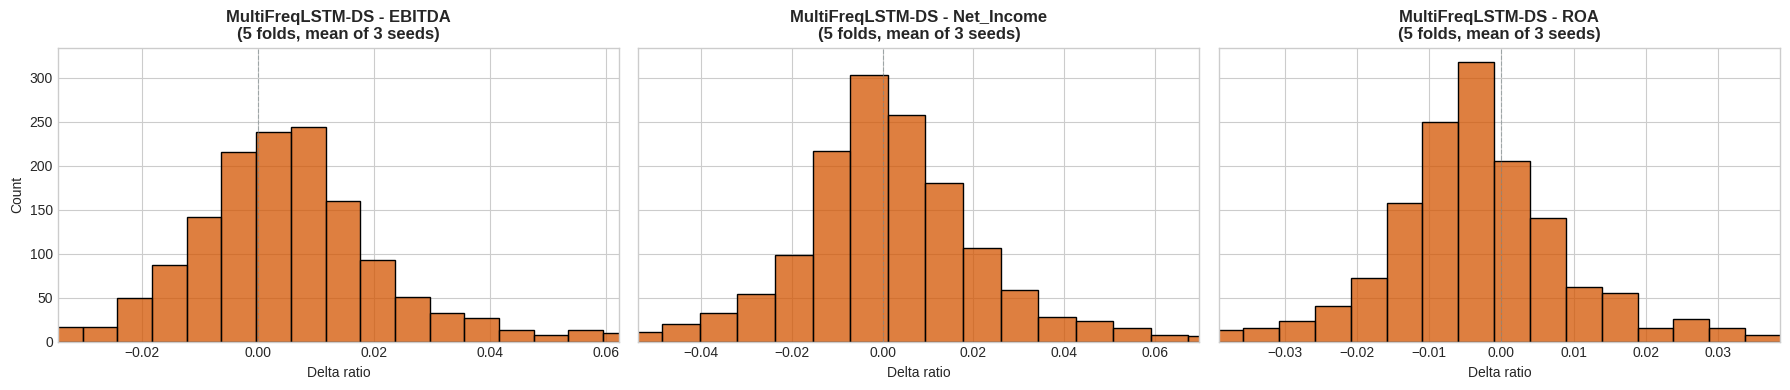

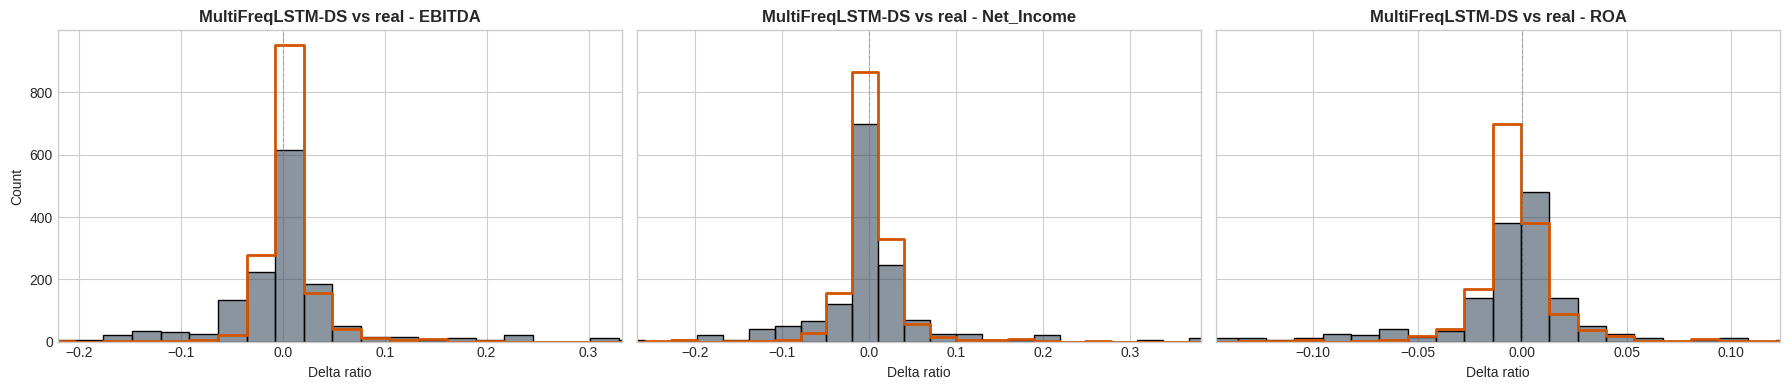

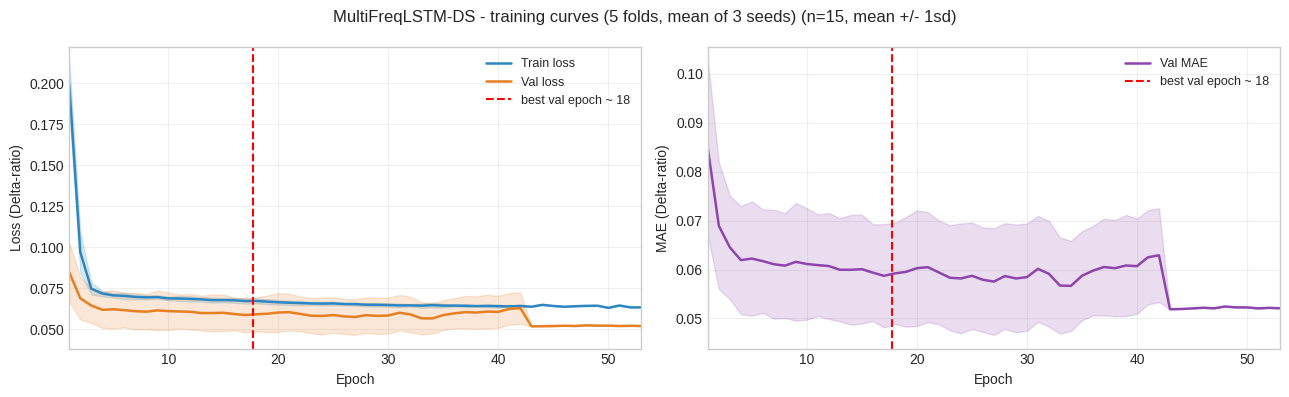

In [ ]:
def make_E_for_fold(params, tr_df, va_df):
    return make_multifreq_ds_loaders_for_fold(tr_df, va_df, params)

if 'params_E' not in globals() or not params_E:
    raise RuntimeError(
        "Model E Optuna results are empty. Run the Model E Optuna cell and the "
        "Model E final-test cell before running this cell."
    )
print("MultiFreqLSTM-DS per-fold test:")
_t0 = _time.time()
per_fold_E = run_per_fold_final(
    make_E_for_fold, params_E, fwd_mf, n_seeds=3,
    loss_fn=make_ds_loss_fn(params_E.get('aux_weight', 0.15)),
)
print(f"Time: {(_time.time()-_t0)/60:.1f} min")
plot_prediction_distributions_agg(per_fold_E, "MultiFreqLSTM-DS")
plot_predictions_vs_targets_agg(per_fold_E, "MultiFreqLSTM-DS")
plot_training_curves_agg(per_fold_E, "MultiFreqLSTM-DS")


## Final Comparison Table

In [11]:
MODEL_NAMES = ["Shallow xLSTM", "Stacked xLSTM", "MultiFreqLSTM", "GroupedLSTM", "MultiFreqLSTM-DS"]

SINGLE_SPLIT = {         # {model: {"n_seeds": int, "EBITDA": (m, s), "Net_Income": (m, s), "ROA": (m, s), "Overall": (m, s)}}
    "Shallow xLSTM":     {"n_seeds": 5, "EBITDA": (0.0616, 0.0014), "Net_Income": (0.0585, 0.0007), "ROA": (0.0293, 0.0005), "Overall": (0.0498, 0.0009)},
    "Stacked xLSTM":     {"n_seeds": 5, "EBITDA": (0.0625, 0.0015), "Net_Income": (0.0588, 0.0016), "ROA": (0.0299, 0.0005), "Overall": (0.0504, 0.0010)},
    "MultiFreqLSTM":     {"n_seeds": 5, "EBITDA": (0.0665, 0.0042), "Net_Income": (0.0620, 0.0040), "ROA": (0.0341, 0.0062), "Overall": (0.0542, 0.0024)},
    "GroupedLSTM":       {"n_seeds": 5, "EBITDA": (0.0629, 0.0005), "Net_Income": (0.0588, 0.0003), "ROA": (0.0297, 0.0002), "Overall": (0.0505, 0.0002)},
    "MultiFreqLSTM-DS":  {"n_seeds": 5, "EBITDA": (0.0625, 0.0015), "Net_Income": (0.0621, 0.0022), "ROA": (0.0315, 0.0009), "Overall": (0.0520, 0.0012)},
}

PER_FOLD = {             # {model: {val_year: overall_mae}}
    "Shallow xLSTM":     {2019: 0.0608, 2020: 0.0670, 2021: 0.0540, 2022: 0.0514, 2023: 0.0501},
    "Stacked xLSTM":     {2019: 0.0723, 2020: 0.0516, 2021: 0.0508, 2022: 0.0502, 2023: 0.0492},
    "MultiFreqLSTM":     {2019: 0.0754, 2020: 0.0702, 2021: 0.0616, 2022: 0.0570, 2023: 0.0531},
    "GroupedLSTM":       {2019: 0.0515, 2020: 0.0544, 2021: 0.0527, 2022: 0.0512, 2023: 0.0505},
    "MultiFreqLSTM-DS":  {2019: 0.0568, 2020: 0.0555, 2021: 0.0516, 2022: 0.0505, 2023: 0.0512},
}

OPTUNA_VAL = {           # {model: best_val_mae}
    "Shallow xLSTM":     0.04308922588825226,
    "Stacked xLSTM":     0.04275684058666229,
    "MultiFreqLSTM":     0.04380128160119057,
    "GroupedLSTM":       0.04305528476834297,
    "MultiFreqLSTM-DS":  0.04368826374411583,
}

BEST_PARAMS = {          # {model: best_params_dict}
    "Shallow xLSTM": {'hidden_size': 128, 'lr': 0.004060889074867581, 'batch_size': 32,
                      'weight_decay': 0.0007847416305712148, 'dropout': 0.09263477550704546,
                      'num_heads': 2, 'proj_factor': 1.0, 'block_type': 'slstm'},
    "Stacked xLSTM": {'hidden_size': 128, 'lr': 0.0048553228141650995, 'batch_size': 16,
                      'weight_decay': 1.4414219304614172e-06, 'dropout': 0.25811340240847697,
                      'num_heads': 4, 'proj_factor': 2.0, 'num_blocks': 3, 'slstm_placement': 'last'},
    "MultiFreqLSTM": {'batch_size': 64, 'lr': 0.0005537423504723057,
                      'weight_decay': 1.0998221237042259e-06, 'dropout': 0.16788408358369425},
    "GroupedLSTM": {'batch_size': 64, 'lr': 0.00450725961161414,
                    'weight_decay': 7.841453642221816e-06, 'dropout': 0.10422355878323203},
    "MultiFreqLSTM-DS": {'batch_size': 16, 'lr': 0.0013339003969520073,
                         'weight_decay': 8.154145546759695e-06, 'dropout': 0.4453009772111255,
                         'aux_weight': 0.0},
}

RAW_SCALE_SPLIT = {      # {model: {target: {"nmae_pct": (m, s), "r2": (m, s)}}}
    "Shallow xLSTM": {
        "EBITDA":     {"nmae_pct": (32.5, 0.6),  "r2": (0.386, 0.023)},
        "Net_Income": {"nmae_pct": (58.9, 1.6),  "r2": (-0.138, 0.094)},
        "ROA":        {"nmae_pct": (53.9, 1.0),  "r2": (0.421, 0.004)},
    },
    "Stacked xLSTM": {
        "EBITDA":     {"nmae_pct": (33.3, 2.5),  "r2": (0.383, 0.097)},
        "Net_Income": {"nmae_pct": (60.6, 7.6),  "r2": (-0.185, 0.286)},
        "ROA":        {"nmae_pct": (55.1, 0.8),  "r2": (0.421, 0.010)},
    },
    "MultiFreqLSTM": {
        "EBITDA":     {"nmae_pct": (34.8, 3.9),  "r2": (0.336, 0.138)},
        "Net_Income": {"nmae_pct": (63.1, 4.1),  "r2": (-0.209, 0.261)},
        "ROA":        {"nmae_pct": (62.2, 10.8), "r2": (0.397, 0.044)},
    },
    "GroupedLSTM": {
        "EBITDA":     {"nmae_pct": (32.0, 1.3),  "r2": (0.395, 0.044)},
        "Net_Income": {"nmae_pct": (59.8, 1.7),  "r2": (-0.263, 0.099)},
        "ROA":        {"nmae_pct": (54.7, 0.3),  "r2": (0.442, 0.013)},
    },
    "MultiFreqLSTM-DS": {
        "EBITDA":     {"nmae_pct": (34.1, 2.9),  "r2": (0.324, 0.116)},
        "Net_Income": {"nmae_pct": (64.1, 2.3),  "r2": (-0.256, 0.084)},
        "ROA":        {"nmae_pct": (57.7, 1.5),  "r2": (0.411, 0.011)},
    },
}

PER_FOLD_RAW_SCALE = {   # {model: {"nmae_pct": (m, s), "r2": (m, s)}} (trained cross-fold avg)
    "Shallow xLSTM":     {"nmae_pct": (53.5, 5.4), "r2": (0.28, 0.08)},
    "Stacked xLSTM":     {"nmae_pct": (52.4, 7.9), "r2": (0.23, 0.04)},
    "MultiFreqLSTM":     {"nmae_pct": (62.3, 8.8), "r2": (0.11, 0.10)},
    "GroupedLSTM":       {"nmae_pct": (49.4, 1.5), "r2": (0.24, 0.06)},
    "MultiFreqLSTM-DS":  {"nmae_pct": (53.8, 2.8), "r2": (0.09, 0.06)},
}

def pf_summary(pf):
    """Mean +/- std of per-fold means (std across the 5 fold means, population)."""
    means = list(pf.values())
    return f"{np.mean(means):.4f} ± {np.std(means):.4f}"

pf_str = {m: pf_summary(PER_FOLD[m]) for m in PER_FOLD}

if SINGLE_SPLIT:
    print("Per-fold test MAE (Overall), per validation year:")
    for m, pf in PER_FOLD.items():
        years = sorted(pf.keys())
        print(f"  {m:28s}: " + ", ".join(f"{y}: {pf[y]:.4f}" for y in years))
    print()
    print("Single-split test MAE (Overall):")
    for m, r in SINGLE_SPLIT.items():
        print(f"  {m:28s} (n={r['n_seeds']} seeds): {r['Overall'][0]:.4f} ± {r['Overall'][1]:.4f}")
else:
    print("Cached result tables are EMPTY (reset for the xLSTM conversion).")
    print("Re-run the Optuna, final-test and per-fold cells for every model, then "
          "refill SINGLE_SPLIT / PER_FOLD / OPTUNA_VAL / BEST_PARAMS / RAW_SCALE_SPLIT / "
          "PER_FOLD_RAW_SCALE in this cell before building the comparison table.")


Per-fold test MAE (Overall), per validation year:
  Shallow xLSTM               : 2019: 0.0608, 2020: 0.0670, 2021: 0.0540, 2022: 0.0514, 2023: 0.0501
  Stacked xLSTM               : 2019: 0.0723, 2020: 0.0516, 2021: 0.0508, 2022: 0.0502, 2023: 0.0492
  MultiFreqLSTM               : 2019: 0.0754, 2020: 0.0702, 2021: 0.0616, 2022: 0.0570, 2023: 0.0531
  GroupedLSTM                 : 2019: 0.0515, 2020: 0.0544, 2021: 0.0527, 2022: 0.0512, 2023: 0.0505
  MultiFreqLSTM-DS            : 2019: 0.0568, 2020: 0.0555, 2021: 0.0516, 2022: 0.0505, 2023: 0.0512

Single-split test MAE (Overall):
  Shallow xLSTM                (n=5 seeds): 0.0498 ± 0.0009
  Stacked xLSTM                (n=5 seeds): 0.0504 ± 0.0010
  MultiFreqLSTM                (n=5 seeds): 0.0542 ± 0.0024
  GroupedLSTM                  (n=5 seeds): 0.0505 ± 0.0002
  MultiFreqLSTM-DS             (n=5 seeds): 0.0520 ± 0.0012


In [14]:
if not SINGLE_SPLIT:
    raise RuntimeError(
        "Result tables are empty (reset for the xLSTM conversion). Re-run the "
        "Optuna + final-test + per-fold cells for every model and refill "
        "SINGLE_SPLIT / PER_FOLD / OPTUNA_VAL / BEST_PARAMS / RAW_SCALE_SPLIT / "
        "PER_FOLD_RAW_SCALE in the previous cell."
    )

_persist_yt = np.vstack(mtl_test_data["label_value"].to_numpy()).astype(float)
_persist_mask = ~np.isnan(_persist_yt)
PERSIST_SINGLE = {}
for _i, _t in enumerate(PREDICTION_TARGETS):
    PERSIST_SINGLE[_t] = (float(np.mean(np.abs(_persist_yt[_persist_mask[:, _i], _i]))), 0.0)
PERSIST_SINGLE["Overall"] = (float(np.mean([PERSIST_SINGLE[_t][0] for _t in PREDICTION_TARGETS])), 0.0)
_persist_raw = raw_mae_delta_ratio(np.zeros_like(_persist_yt), test_meta)
PERSIST_RAW_SCALE = {
    _t: {"nmae_pct": (_persist_raw[_t]["nmae_pct"], 0.0),
         "r2": (_persist_raw[_t]["r2"], 0.0)}
    for _t in PREDICTION_TARGETS
}
print("Persistence (no-change) baseline on the final test set:")
for _t in PREDICTION_TARGETS:
    print(f"  {_t:11s}: MAE {PERSIST_SINGLE[_t][0]:.4f} | raw MAE {_persist_raw[_t]['mae']:.4f} "
          f"| nMAE {PERSIST_RAW_SCALE[_t]['nmae_pct'][0]:.1f}% | R2 {PERSIST_RAW_SCALE[_t]['r2'][0]:+.3f}")
print(f"  {'Overall':11s}: MAE {PERSIST_SINGLE['Overall'][0]:.4f}")

summary = pd.DataFrame([
    {
        "Model": m,
        "Best Optuna val MAE": OPTUNA_VAL[m],
        "Test MAE (EBITDA margin)": f"{SINGLE_SPLIT[m]['EBITDA'][0]:.4f} ± {SINGLE_SPLIT[m]['EBITDA'][1]:.4f}",
        "Test MAE (net margin)": f"{SINGLE_SPLIT[m]['Net_Income'][0]:.4f} ± {SINGLE_SPLIT[m]['Net_Income'][1]:.4f}",
        "Test MAE (ROA)": f"{SINGLE_SPLIT[m]['ROA'][0]:.4f} ± {SINGLE_SPLIT[m]['ROA'][1]:.4f}",
        "Test MAE (Overall)": f"{SINGLE_SPLIT[m]['Overall'][0]:.4f} ± {SINGLE_SPLIT[m]['Overall'][1]:.4f}",
        "nMAE EBITDA (%)": f"{RAW_SCALE_SPLIT[m]['EBITDA']['nmae_pct'][0]:.1f}% ± {RAW_SCALE_SPLIT[m]['EBITDA']['nmae_pct'][1]:.1f}%",
        "nMAE Net_Income (%)": f"{RAW_SCALE_SPLIT[m]['Net_Income']['nmae_pct'][0]:.1f}% ± {RAW_SCALE_SPLIT[m]['Net_Income']['nmae_pct'][1]:.1f}%",
        "nMAE ROA (%)": f"{RAW_SCALE_SPLIT[m]['ROA']['nmae_pct'][0]:.1f}% ± {RAW_SCALE_SPLIT[m]['ROA']['nmae_pct'][1]:.1f}%",
        "R² EBITDA": f"{RAW_SCALE_SPLIT[m]['EBITDA']['r2'][0]:.3f} ± {RAW_SCALE_SPLIT[m]['EBITDA']['r2'][1]:.3f}",
        "R² Net_Income": f"{RAW_SCALE_SPLIT[m]['Net_Income']['r2'][0]:.3f} ± {RAW_SCALE_SPLIT[m]['Net_Income']['r2'][1]:.3f}",
        "R² ROA": f"{RAW_SCALE_SPLIT[m]['ROA']['r2'][0]:.3f} ± {RAW_SCALE_SPLIT[m]['ROA']['r2'][1]:.3f}",
        "Per-fold test MAE": pf_str[m],
        "Per-fold nMAE (avg %)": f"{PER_FOLD_RAW_SCALE[m]['nmae_pct'][0]:.1f}% ± {PER_FOLD_RAW_SCALE[m]['nmae_pct'][1]:.1f}%",
        "Per-fold R2 (avg)": f"{PER_FOLD_RAW_SCALE[m]['r2'][0]:.2f} ± {PER_FOLD_RAW_SCALE[m]['r2'][1]:.2f}",
        "Best params": str(BEST_PARAMS[m]),
    }
    for m in MODEL_NAMES
])
# Append the persistence reference row (deterministic: no std, no per-fold variation)
summary = pd.concat([summary, pd.DataFrame([{
    "Model": "Persistence (no-change)",
    "Best Optuna val MAE": np.nan,
    "Test MAE (EBITDA margin)": f"{PERSIST_SINGLE['EBITDA'][0]:.4f}",
    "Test MAE (net margin)": f"{PERSIST_SINGLE['Net_Income'][0]:.4f}",
    "Test MAE (ROA)": f"{PERSIST_SINGLE['ROA'][0]:.4f}",
    "Test MAE (Overall)": f"{PERSIST_SINGLE['Overall'][0]:.4f}",
    "nMAE EBITDA (%)": f"{PERSIST_RAW_SCALE['EBITDA']['nmae_pct'][0]:.1f}%",
    "nMAE Net_Income (%)": f"{PERSIST_RAW_SCALE['Net_Income']['nmae_pct'][0]:.1f}%",
    "nMAE ROA (%)": f"{PERSIST_RAW_SCALE['ROA']['nmae_pct'][0]:.1f}%",
    "R² EBITDA": f"{PERSIST_RAW_SCALE['EBITDA']['r2'][0]:+.3f}",
    "R² Net_Income": f"{PERSIST_RAW_SCALE['Net_Income']['r2'][0]:+.3f}",
    "R² ROA": f"{PERSIST_RAW_SCALE['ROA']['r2'][0]:+.3f}",
    "Per-fold test MAE": "—",
    "Per-fold nMAE (avg %)": "—",
    "Per-fold R2 (avg)": "—",
    "Best params": "predict Delta-ratio = 0 (ratio_t = ratio_{t-1})",
}])], ignore_index=True)
display(summary)

# Best model by single-split headline number (trained models only: the
# persistence row is the reference baseline, not a candidate)
summary_models = summary[summary["Model"] != "Persistence (no-change)"].reset_index(drop=True)
best_idx = summary_models["Test MAE (Overall)"].apply(lambda s: float(s.split(' ± ')[0])).idxmin()
print(f"\nBest model by single-split test Overall MAE: {summary_models.loc[best_idx, 'Model']}")
print(f"  Test MAE (Overall): {summary_models.loc[best_idx, 'Test MAE (Overall)']}")
print(f"  Per-fold test MAE:   {summary_models.loc[best_idx, 'Per-fold test MAE']}")

# Best model by per-fold test MAE
best_pf_idx = summary_models["Per-fold test MAE"].apply(lambda s: float(s.split(' ± ')[0])).idxmin()
print(f"\nBest model by per-fold test MAE: {summary_models.loc[best_pf_idx, 'Model']}")
print(f"  Per-fold test MAE:   {summary_models.loc[best_pf_idx, 'Per-fold test MAE']}")

Persistence (no-change) baseline on the final test set:
  EBITDA     : MAE 0.0633 | raw MAE 262129.2050 | nMAE 32.9% | R2 +0.385
  Net_Income : MAE 0.0615 | raw MAE 222308.6585 | nMAE 66.0% | R2 -0.391
  ROA        : MAE 0.0304 | raw MAE 0.0321 | nMAE 55.9% | R2 +0.391
  Overall    : MAE 0.0517


,Model,Best Optuna val MAE,Test MAE (EBITDA margin),Test MAE (net margin),Test MAE (ROA),Test MAE (Overall),nMAE EBITDA (%),nMAE Net_Income (%),nMAE ROA (%),R² EBITDA,R² Net_Income,R² ROA,Per-fold test MAE,Per-fold nMAE (avg %),Per-fold R2 (avg),Best params
0,Shallow xLSTM,0.043089,0.0616 ± 0.0014,0.0585 ± 0.0007,0.0293 ± 0.0005,0.0498 ± 0.0009,32.5% ± 0.6%,58.9% ± 1.6%,53.9% ± 1.0%,0.386 ± 0.023,-0.138 ± 0.094,0.421 ± 0.004,0.0567 ± 0.0064,53.5% ± 5.4%,0.28 ± 0.08,"{'hidden_size': 128, 'lr': 0.00406088907486758..."
1,Stacked xLSTM,0.042757,0.0625 ± 0.0015,0.0588 ± 0.0016,0.0299 ± 0.0005,0.0504 ± 0.0010,33.3% ± 2.5%,60.6% ± 7.6%,55.1% ± 0.8%,0.383 ± 0.097,-0.185 ± 0.286,0.421 ± 0.010,0.0548 ± 0.0088,52.4% ± 7.9%,0.23 ± 0.04,"{'hidden_size': 128, 'lr': 0.00485532281416509..."
2,MultiFreqLSTM,0.043801,0.0665 ± 0.0042,0.0620 ± 0.0040,0.0341 ± 0.0062,0.0542 ± 0.0024,34.8% ± 3.9%,63.1% ± 4.1%,62.2% ± 10.8%,0.336 ± 0.138,-0.209 ± 0.261,0.397 ± 0.044,0.0635 ± 0.0083,62.3% ± 8.8%,0.11 ± 0.10,"{'batch_size': 64, 'lr': 0.0005537423504723057..."
3,GroupedLSTM,0.043055,0.0629 ± 0.0005,0.0588 ± 0.0003,0.0297 ± 0.0002,0.0505 ± 0.0002,32.0% ± 1.3%,59.8% ± 1.7%,54.7% ± 0.3%,0.395 ± 0.044,-0.263 ± 0.099,0.442 ± 0.013,0.0521 ± 0.0014,49.4% ± 1.5%,0.24 ± 0.06,"{'batch_size': 64, 'lr': 0.00450725961161414, ..."
4,MultiFreqLSTM-DS,0.043688,0.0625 ± 0.0015,0.0621 ± 0.0022,0.0315 ± 0.0009,0.0520 ± 0.0012,34.1% ± 2.9%,64.1% ± 2.3%,57.7% ± 1.5%,0.324 ± 0.116,-0.256 ± 0.084,0.411 ± 0.011,0.0531 ± 0.0025,53.8% ± 2.8%,0.09 ± 0.06,"{'batch_size': 16, 'lr': 0.0013339003969520073..."
5,Persistence (no-change),NaN,0.0633,0.0615,0.0304,0.0517,32.9%,66.0%,55.9%,+0.385,-0.391,+0.391,—,—,—,predict Delta-ratio = 0 (ratio_t = ratio_{t-1})



Best model by single-split test Overall MAE: Shallow xLSTM
  Test MAE (Overall): 0.0498 ± 0.0009
  Per-fold test MAE:   0.0567 ± 0.0064

Best model by per-fold test MAE: GroupedLSTM
  Per-fold test MAE:   0.0521 ± 0.0014


## 2025 as Validation

In [ ]:
TRAIN_MAX_YEAR_FV = 2022
VAL_YEAR_FV      = 2025
TEST_YEARS_FV    = [2023, 2024]

train_fv        = data_df[data_df["year"] <= TRAIN_MAX_YEAR_FV].copy().reset_index(drop=True)
val_fv          = data_df[data_df["year"] == VAL_YEAR_FV].copy().reset_index(drop=True)
test_2023_fv    = data_df[data_df["year"] == 2023].copy().reset_index(drop=True)
test_2024_fv    = data_df[data_df["year"] == 2024].copy().reset_index(drop=True)
test_combined_fv = pd.concat([test_2023_fv, test_2024_fv], ignore_index=True)

print(f"Train (year <= {TRAIN_MAX_YEAR_FV}): {len(train_fv)} samples")
print(f"Val   (year == {VAL_YEAR_FV}): {len(val_fv)} samples")
print(f"Test 2023: {len(test_2023_fv)} samples")
print(f"Test 2024: {len(test_2024_fv)} samples")
print(f"Test 2023+2024 (combined): {len(test_combined_fv)} samples")

mtl_train_fv_raw         = extract_mtl_df(train_fv)
mtl_val_fv_raw           = extract_mtl_df(val_fv)
mtl_test_2023_fv_raw     = extract_mtl_df(test_2023_fv)
mtl_test_2024_fv_raw     = extract_mtl_df(test_2024_fv)
mtl_test_combined_fv_raw = extract_mtl_df(test_combined_fv)

stat_sc_fv = fit_static_scaler(mtl_train_fv_raw, NEW_STATIC_SLICE)
mtl_train_fv         = apply_static_scaler(mtl_train_fv_raw,         stat_sc_fv, NEW_STATIC_SLICE)
mtl_val_fv_s         = apply_static_scaler(mtl_val_fv_raw,           stat_sc_fv, NEW_STATIC_SLICE)
mtl_test_2023_fv     = apply_static_scaler(mtl_test_2023_fv_raw,     stat_sc_fv, NEW_STATIC_SLICE)
mtl_test_2024_fv     = apply_static_scaler(mtl_test_2024_fv_raw,     stat_sc_fv, NEW_STATIC_SLICE)
mtl_test_combined_fv = apply_static_scaler(mtl_test_combined_fv_raw, stat_sc_fv, NEW_STATIC_SLICE)


In [ ]:
def build_loaders_fv(params, num_blocks: int):
    """Build train/val/test23/test24/test_combined loaders + Stacked xLSTM for the FV setup.
    Scalers fit on the FV-train fold only (no leakage from val=2025 or test 2023/2024).
    """
    temp_sc = make_robust_scaler(mtl_train_fv_raw, selected_indices)
    train_ds  = YoYDatasetMTL(mtl_train_fv,         temp_sc, selected_indices)
    val_ds    = YoYDatasetMTL(mtl_val_fv_s,         temp_sc, selected_indices)
    t23_ds    = YoYDatasetMTL(mtl_test_2023_fv,     temp_sc, selected_indices)
    t24_ds    = YoYDatasetMTL(mtl_test_2024_fv,     temp_sc, selected_indices)
    tc_ds     = YoYDatasetMTL(mtl_test_combined_fv, temp_sc, selected_indices)

    bs = params["batch_size"]
    train_loader         = DataLoader(train_ds, batch_size=bs, shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader           = DataLoader(val_ds,   batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)
    test23_loader        = DataLoader(t23_ds,   batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)
    test24_loader        = DataLoader(t24_ds,   batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)
    test_combined_loader = DataLoader(tc_ds,    batch_size=bs, shuffle=False, collate_fn=collate_fn_mtl)

    model = StackedXLSTM(
        len(selected_indices), params["hidden_size"],
        num_blocks=num_blocks, num_targets=len(PREDICTION_TARGETS),
        dropout=params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP,
        slstm_at=_slstm_at(params, num_blocks),
        num_heads=params.get("num_heads", 4),
        proj_factor=params.get("proj_factor", 2.0),
    ).to(DEVICE)
    return model, train_loader, val_loader, test23_loader, test24_loader, test_combined_loader


def eval_mae_per_target(model, loader):
    """Per-target MAE in Delta-ratio space."""
    return evaluate_loader(model, loader, fwd_mtl)


In [ ]:
FV_DEPTHS = [1, 2, 3, 4]
N_SEEDS_FV = 5

if "study_B" not in globals():
    raise RuntimeError(
        "study_B is not defined. Re-run the Stacked xLSTM Optuna cell (cell 24) "
        "so params_B reflects the corrected label construction."
    )
params_B_fv = dict(study_B.best_trial.params)
print(f"Using study_B best params (fixed across depths): {params_B_fv}")

fv_depth_results = []
fv_depth_best_epochs = {}
fv_histories = {}
fv_preds = {}

for nl in FV_DEPTHS:
    for seed_offset in range(N_SEEDS_FV):
        seed = SEED + seed_offset
        np.random.seed(seed)
        torch.manual_seed(seed)

        model, tr_loader, va_loader, t23_loader, t24_loader, tc_loader = \
            build_loaders_fv(params_B_fv, num_blocks=nl)
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=params_B_fv["lr"],
            weight_decay=params_B_fv["weight_decay"],
        )

        # Use this notebook's training loop: L1, ReduceLROnPlateau, early stopping,
        # grad_clip=1.0, MAX_EPOCHS=100. Returns best_val_mae (real-space), best_epoch,
        # and (collect_history=True) the per-epoch history dict.
        model, best_val_mae, best_epoch, history = train_and_eval(
            model, tr_loader, va_loader, optimizer, fwd_mtl,
            collect_history=True
        )
        fv_histories.setdefault(nl, {})[seed] = history

        val_mae            = eval_mae_per_target(model, va_loader)
        test23_mae         = eval_mae_per_target(model, t23_loader)
        test24_mae         = eval_mae_per_target(model, t24_loader)
        test_combined_mae  = eval_mae_per_target(model, tc_loader)

        # Collect test predictions (2023+2024) for distribution plots.
        preds, targets, mask = collect_predictions(model, tc_loader, fwd_mtl)
        fv_preds.setdefault(nl, {})[seed] = (preds, targets, mask)

        for tgt in PREDICTION_TARGETS + ["Overall"]:
            fv_depth_results.append({
                "num_blocks": nl, "seed": seed, "target": tgt,
                "val_2025_mae":      val_mae.get(tgt),
                "test_2023_mae":     test23_mae.get(tgt),
                "test_2024_mae":     test24_mae.get(tgt),
                "test_combined_mae": test_combined_mae.get(tgt),
                "best_val_mae":      best_val_mae,
                "best_epoch":        best_epoch,
            })
        fv_depth_best_epochs[(nl, seed)] = best_epoch
        print(f"[B={nl} seed={seed_offset}] val_2025={val_mae['Overall']:.4f} "
              f"test_2023={test23_mae['Overall']:.4f} test_2024={test24_mae['Overall']:.4f} "
              f"test_combined={test_combined_mae['Overall']:.4f} "
              f"best_val_mae={best_val_mae:.4f} @ ep {best_epoch}")

df_fv_runs = pd.DataFrame(fv_depth_results)
print(f"\n=== Block sweep ({FV_DEPTHS} blocks) \u2014 Train <= 2022, Val = 2025, Test = 2023 & 2024 ===")
print(f"Total runs: {len(df_fv_runs) // 4} (={len(FV_DEPTHS)} blocks x {N_SEEDS_FV} seeds)")


In [ ]:
def fv_agg_mean_std(grp):
    metrics = ["val_2025_mae", "test_2023_mae", "test_2024_mae",
               "test_combined_mae", "best_val_mae", "best_epoch"]
    out = [int(len(grp))]
    for m in metrics:
        out.append(float(grp[m].mean()))
        out.append(float(grp[m].std()))
    return out

result = df_fv_runs.groupby(["num_blocks", "target"]).apply(fv_agg_mean_std)
df_fv_summary = pd.DataFrame(result.tolist(), index=result.index).reset_index()
df_fv_summary.columns = [
    "num_blocks", "target", "n_seeds",
    "val_2025_mae_mean", "val_2025_mae_std",
    "test_2023_mae_mean", "test_2023_mae_std",
    "test_2024_mae_mean", "test_2024_mae_std",
    "test_combined_mae_mean", "test_combined_mae_std",
    "best_val_mae_mean", "best_val_mae_std",
    "best_epoch_mean", "best_epoch_std",
]
display(df_fv_summary.round(4))

val_by_depth       = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_blocks")["val_2025_mae_mean"]
test23_by_depth    = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_blocks")["test_2023_mae_mean"]
test24_by_depth    = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_blocks")["test_2024_mae_mean"]
test_comb_by_depth = df_fv_summary[df_fv_summary["target"] == "Overall"].set_index("num_blocks")["test_combined_mae_mean"]

print("\n=== Verdict (FV, depth only, params from study_B) ===")
for metric_name, series in [
    ("Selection (val_2025)", val_by_depth),
    ("Test MAE (2023)",       test23_by_depth),
    ("Test MAE (2024)",       test24_by_depth),
    ("Test MAE (2023+2024)",  test_comb_by_depth),
]:
    best_L = series.idxmin()
    print(f"  {metric_name:25s}: best B={best_L} ({series[best_L]:.4f})")

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))
xs = np.arange(len(FV_DEPTHS))
width = 0.6
for i, (col, title) in enumerate([
    ("val_2025_mae_mean",     "Val MAE (2025, future)"),
    ("test_2023_mae_mean",    "Test MAE (2023)"),
    ("test_2024_mae_mean",    "Test MAE (2024)"),
    ("test_combined_mae_mean","Test MAE (2023+2024)"),
]):
    means = [df_fv_summary[(df_fv_summary["num_blocks"] == L) & (df_fv_summary["target"] == "Overall")][col].iloc[0] for L in FV_DEPTHS]
    stds  = [df_fv_summary[(df_fv_summary["num_blocks"] == L) & (df_fv_summary["target"] == "Overall")][col.replace("mean","std")].iloc[0] for L in FV_DEPTHS]
    ax[i].bar(xs, means, width, yerr=stds, capsize=4, color="steelblue", edgecolor="black")
    ax[i].set_xticks(xs); ax[i].set_xticklabels([f"B={L}" for L in FV_DEPTHS])
    ax[i].set_title(title); ax[i].set_ylabel("MAE (real space)")
    ax[i].grid(True, alpha=0.3, axis="y")
fig.suptitle(f"FV depth sweep \u2014 Train <= 2022, Val = 2025, Test = 2023 & 2024  (\u03bc \u00b1 \u03c3, n={N_SEEDS_FV})")
plt.tight_layout()
plt.show()

print(f"\n=== Curves & distributions for best block depth (by val_2025 Overall MAE) ===")
best_depth_fv = int(val_by_depth.idxmin())
best_depth_seeds = sorted(fv_histories[best_depth_fv])
print(f"Best depth: B={best_depth_fv} (val_2025 MAE = {val_by_depth[best_depth_fv]:.4f}), "
      f"{len(best_depth_seeds)} seeds: {best_depth_seeds}")

plot_training_curves(
    [fv_histories[best_depth_fv][s] for s in best_depth_seeds],
    f"Stacked xLSTM FV (val=2025) B={best_depth_fv}",
    tag="best depth by val_2025, 5 seeds",
)
plot_prediction_distributions(
    [fv_preds[best_depth_fv][s] for s in best_depth_seeds],
    f"Stacked xLSTM FV (val=2025) B={best_depth_fv}",
)
plot_predictions_vs_targets(
    [fv_preds[best_depth_fv][s] for s in best_depth_seeds],
    f"Stacked xLSTM FV (val=2025) B={best_depth_fv}",
)
